# 05. Plots

✅ Matrizes de Confusão geradas e salvas em: ../reports/figures/matrizes_confusao_comparativo.png


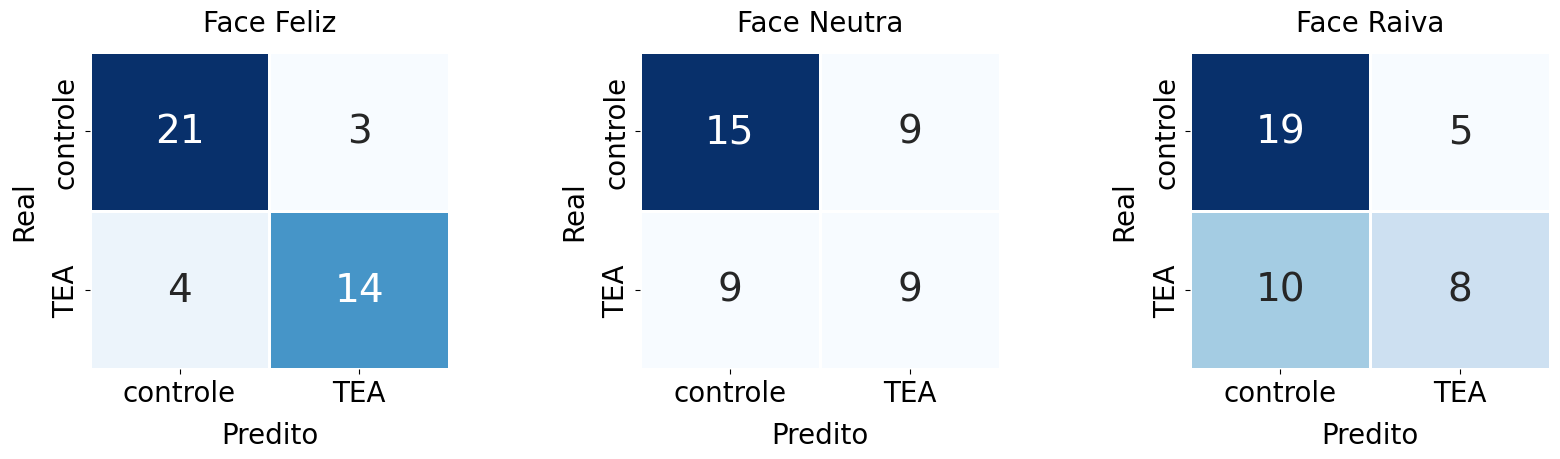

In [1]:
# 01. VISUALIZAÇÃO: MATRIZES DE CONFUSÃO (COMPARATIVO)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix
import warnings
import os

warnings.filterwarnings("ignore")

# 1. Configurações Visuais
plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'font.weight': 'normal',
    'axes.labelweight': 'normal',
    'axes.titleweight': 'normal'
})

# 2. Carregamento de Dados
caminho_csv = '../reports/tabela_features_eeg_completa.csv'
df = pd.read_csv(caminho_csv)

# Lendo os nomes exatos
condicoes_busca = {
    'Face Feliz': ['Face Feliz'],
    'Face Neutra': ['Face Neutra'],
    'Face Raiva': ['Face Raiva']
}

paletas = ['Blues', 'Blues', 'Blues'] # cores

# 3. Pipeline final (XGBoost + k=15)
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', RobustScaler()),
    ('selector', SelectKBest(score_func=f_classif, k=15)),
    ('clf', XGBClassifier(n_estimators=150, max_depth=3, learning_rate=0.1, 
                          eval_metric='logloss', random_state=97))
])

# Definição explícita da estratégia de validação
cv_strategy = LeaveOneOut()

# 4. Preparação do Plot (1 linha, 3 colunas)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('white')

for idx, (nome_condicao, lista_triggers) in enumerate(condicoes_busca.items()):
    df_f = df[df['Condicao'].isin(lista_triggers)].copy()
    
    if df_f.empty:
        axes[idx].set_title(f"{nome_condicao}\n(Sem dados)")
        axes[idx].axis('off')
        continue

    # Garantia do N=42
    df_f = df_f.groupby(['ID', 'Grupo']).mean(numeric_only=True).reset_index()
    y = df_f['Grupo'].apply(lambda x: 1 if 'TEA' in x else 0).values
    X = df_f.drop(columns=['ID', 'Grupo', 'Condicao', 'Tipo'], errors='ignore')

    # Predição com LOOCV
    y_pred = cross_val_predict(pipeline, X, y, cv=cv_strategy)
    cm = confusion_matrix(y, y_pred)

    # Plotagem Individual
    sns.heatmap(cm, annot=True, fmt='d', cmap=paletas[idx], cbar=False, ax=axes[idx],
                xticklabels=['controle', 'TEA'], yticklabels=['controle', 'TEA'],
                annot_kws={"size": 28, "weight": "normal"}, 
                linewidths=2, linecolor='white')
    
    axes[idx].set_title(nome_condicao, pad=15)
    axes[idx].set_ylabel('Real', labelpad=10)
    axes[idx].set_xlabel('Predito', labelpad=10)

plt.tight_layout(w_pad=4.0)

os.makedirs('../reports/figures', exist_ok=True)
caminho_imagem = '../reports/figures/matrizes_confusao_comparativo.png'
plt.savefig(caminho_imagem, dpi=300, bbox_inches='tight')
print(f"✅ Matrizes de Confusão geradas e salvas em: {caminho_imagem}")
plt.show()

⏳ Executando o Benchmark dos Modelos (LOOCV)...
✅ Gráfico gerado! Salvo em: ../reports/figures/fig02_comparativo_modelos.png


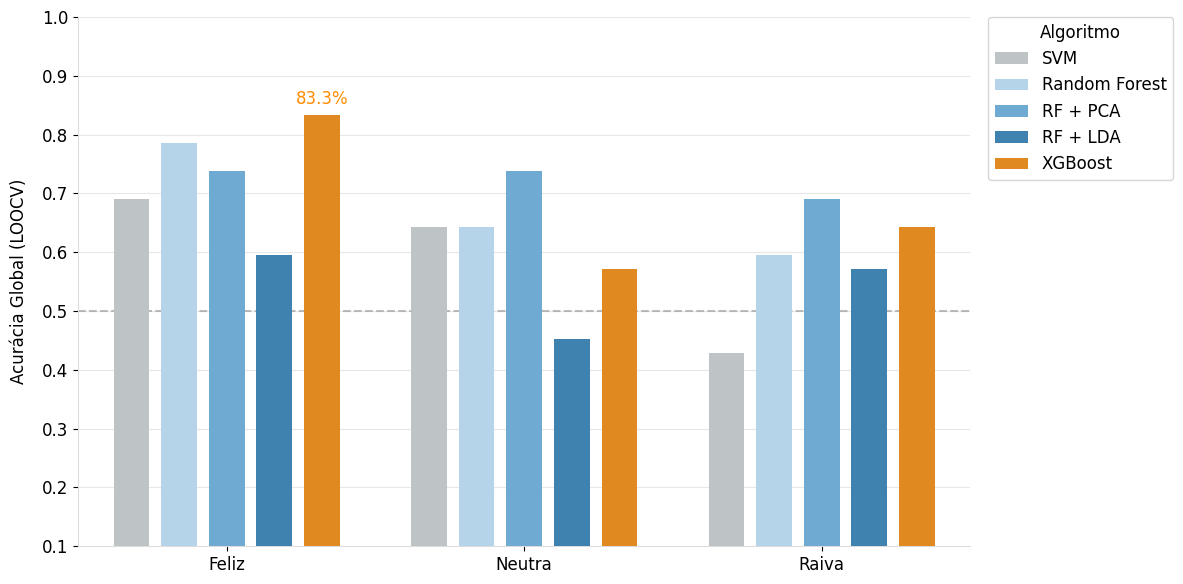

In [2]:
# 02. VISUALIZAÇÃO: BENCHMARK DE ALGORITMOS

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import warnings

warnings.filterwarnings("ignore")

print("⏳ Executando o Benchmark dos Modelos (LOOCV)...")

# 1. Configurações Visuais
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'font.weight': 'normal',
    'axes.labelweight': 'normal',
    'axes.titleweight': 'normal',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

# 2. Carregamento dos Dados
caminho_csv = '../reports/tabela_features_eeg_completa.csv'
df = pd.read_csv(caminho_csv)

condicoes_busca = {
    'Feliz': ['Face Feliz'],
    'Neutra': ['Face Neutra'],
    'Raiva': ['Face Raiva']
}

SEED = 97
cv_strategy = LeaveOneOut()

# 3. Definição dos Pipelines
modelos = {
    'SVM': Pipeline([('i', SimpleImputer()), ('s', RobustScaler()), ('sel', SelectKBest(f_classif, k=15)), 
                     ('clf', SVC(kernel='linear', random_state=SEED))]),
    
    'Random Forest': Pipeline([('i', SimpleImputer()), ('s', RobustScaler()), ('sel', SelectKBest(f_classif, k=15)), 
                               ('clf', RandomForestClassifier(n_estimators=150, max_depth=3, random_state=SEED))]),
    
    'RF + PCA': Pipeline([('i', SimpleImputer()), ('s', RobustScaler()), ('pca', PCA(n_components=10, random_state=SEED)), 
                          ('clf', RandomForestClassifier(n_estimators=150, max_depth=3, random_state=SEED))]),
    
    'RF + LDA': Pipeline([('i', SimpleImputer()), ('s', RobustScaler()), ('lda', LDA()), 
                          ('clf', RandomForestClassifier(n_estimators=150, max_depth=3, random_state=SEED))]),
    
    'XGBoost': Pipeline([('i', SimpleImputer()), ('s', RobustScaler()), ('sel', SelectKBest(f_classif, k=15)), 
                         ('clf', XGBClassifier(n_estimators=150, max_depth=3, learning_rate=0.1, eval_metric='logloss', random_state=SEED))])
}

# 4. Extração de Resultados
resultados = []

for nome_condicao, lista_triggers in condicoes_busca.items():
    df_f = df[df['Condicao'].isin(lista_triggers)].copy()
    if df_f.empty: continue
        
    df_f = df_f.groupby(['ID', 'Grupo']).mean(numeric_only=True).reset_index()
    y = df_f['Grupo'].apply(lambda x: 1 if 'TEA' in x else 0).values
    X = df_f.drop(columns=['ID', 'Grupo', 'Condicao', 'Tipo'], errors='ignore')
    
    for nome_modelo, pipeline in modelos.items():
        acc = cross_val_score(pipeline, X, y, cv=cv_strategy).mean()
        resultados.append({'Condição': nome_condicao, 'Algoritmo': nome_modelo, 'Acurácia': acc})

df_resultados = pd.DataFrame(resultados)

# 5. Plotagem Gráfica
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_axisbelow(True) # Força a grade a ficar atrás das barras

# Cores personalizadas | SVM (Cinza), RF (Azul Claro), RF+PCA (Azul Médio), RF+LDA (Azul Escuro), XGBoost (Laranja)
cores_personalizadas = ['#BDC3C7', '#AED6F1', '#5DADE2', '#2E86C1', '#FF8C00']

# zorder=3 garante que as barras fiquem na camada da frente
sns.barplot(data=df_resultados, x='Condição', y='Acurácia', hue='Algoritmo', 
            palette=cores_personalizadas, edgecolor='none', ax=ax, zorder=3)

# A função de afinar as barras
def change_width(ax, new_value):
    for patch in ax.patches:
        current_width = patch.get_width()
        diff = current_width - new_value
        patch.set_width(new_value)
        patch.set_x(patch.get_x() + diff * .5)

change_width(ax, 0.12)

# Linha de chance a 50% desenhada na camada do meio (zorder=2)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, zorder=2)

ax.set_ylim(0.1, 1.0)
ax.set_ylabel('Acurácia Global (LOOCV)', labelpad=10)
ax.set_xlabel('')

# Grade sutil desenhada na camada do fundo (zorder=1)
ax.grid(axis='y', linestyle='-', alpha=0.3, color='#B0B0B0', zorder=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#DDDDDD')
ax.spines['bottom'].set_color('#DDDDDD')

plt.legend(title='Algoritmo', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

# Destacar a barra campeã com fonte 12
max_acc = df_resultados['Acurácia'].max()
for p in ax.patches:
    altura = p.get_height()
    if abs(altura - max_acc) < 0.001:
        ax.annotate(f'{altura:.1%}', 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), textcoords='offset points', 
                    color='#FF8C00', fontsize=12, fontweight='normal')

plt.tight_layout()

# 6. Salvamento
os.makedirs('../reports/figures', exist_ok=True)
caminho_imagem = '../reports/figures/fig02_comparativo_modelos.png'
plt.savefig(caminho_imagem, dpi=300, bbox_inches='tight')

print(f"✅ Gráfico gerado! Salvo em: {caminho_imagem}")
plt.show()

⏳ Extraindo as regras biológicas do XGBoost para as 3 condições...

------------------------------------------------------------
 PROCESSANDO: FACE FELIZ
------------------------------------------------------------


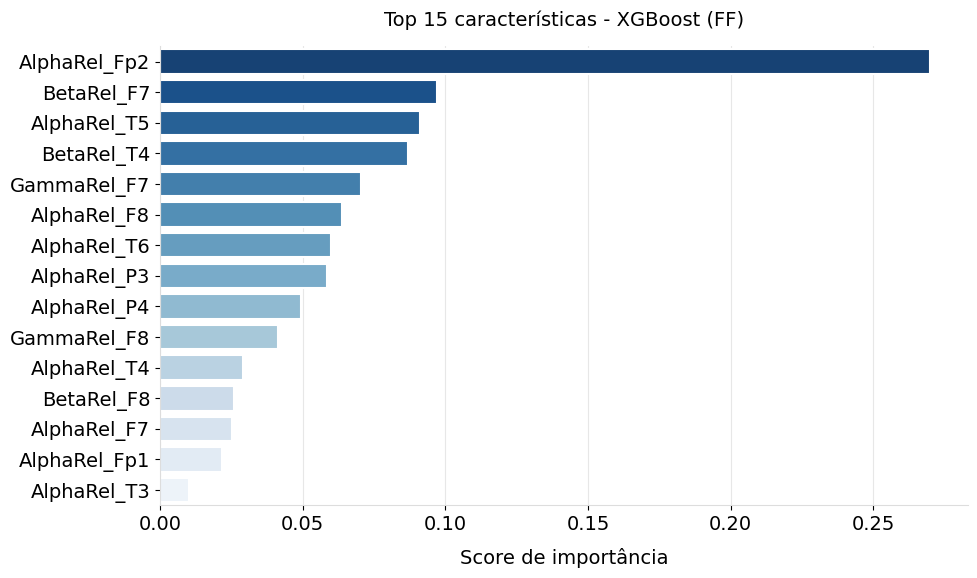

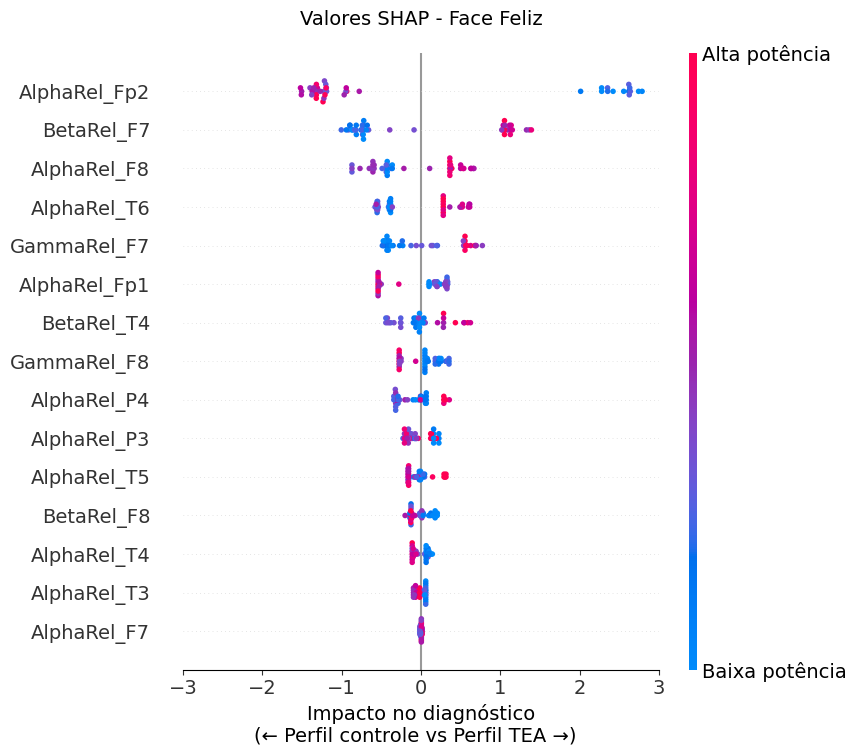


------------------------------------------------------------
 PROCESSANDO: FACE NEUTRA
------------------------------------------------------------


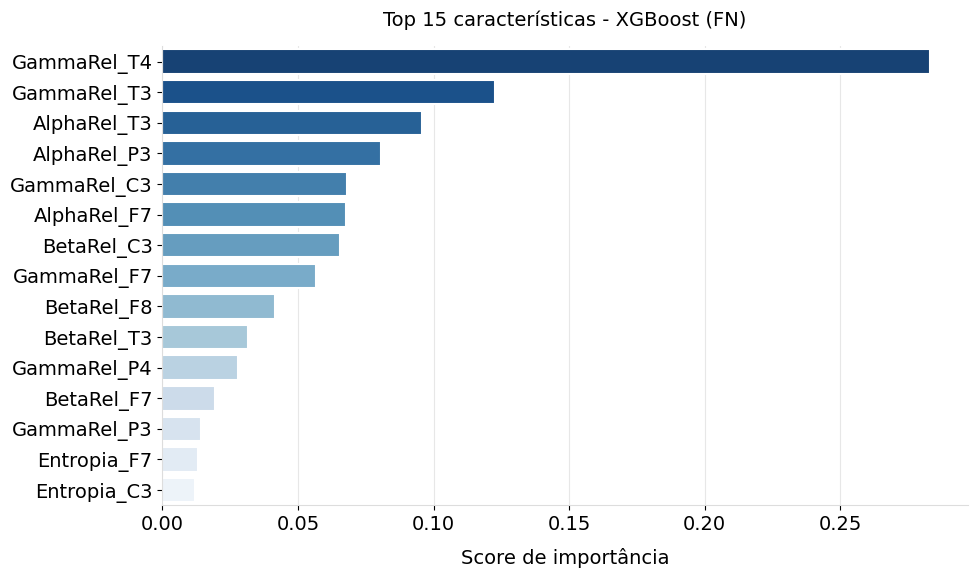

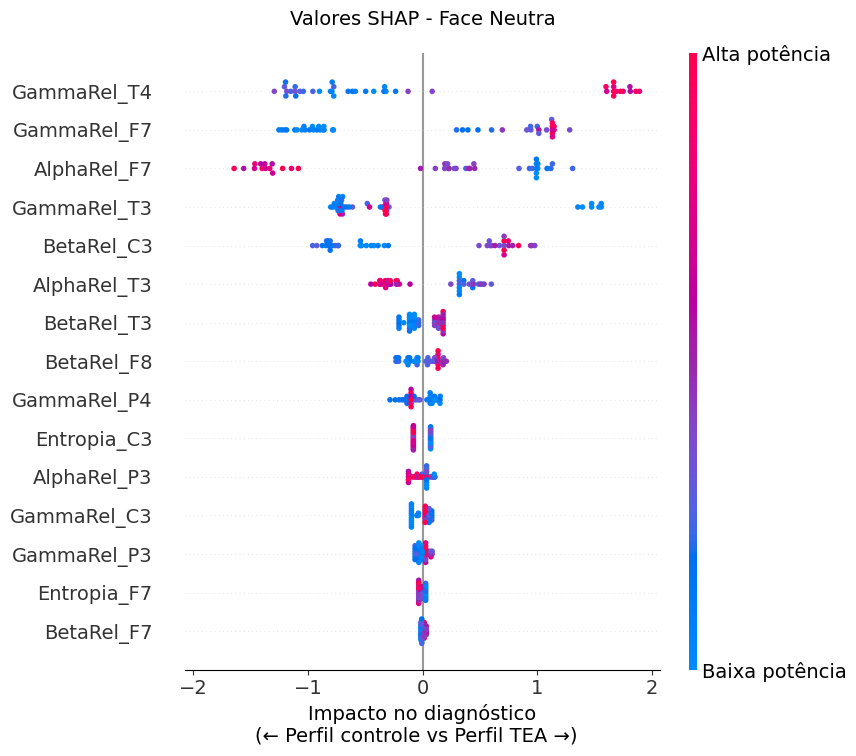


------------------------------------------------------------
 PROCESSANDO: FACE RAIVA
------------------------------------------------------------


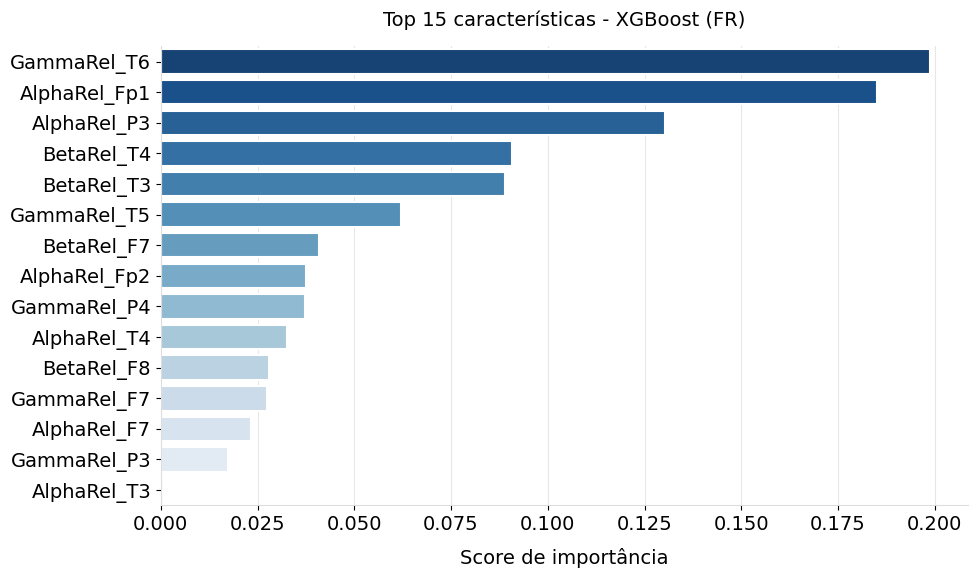

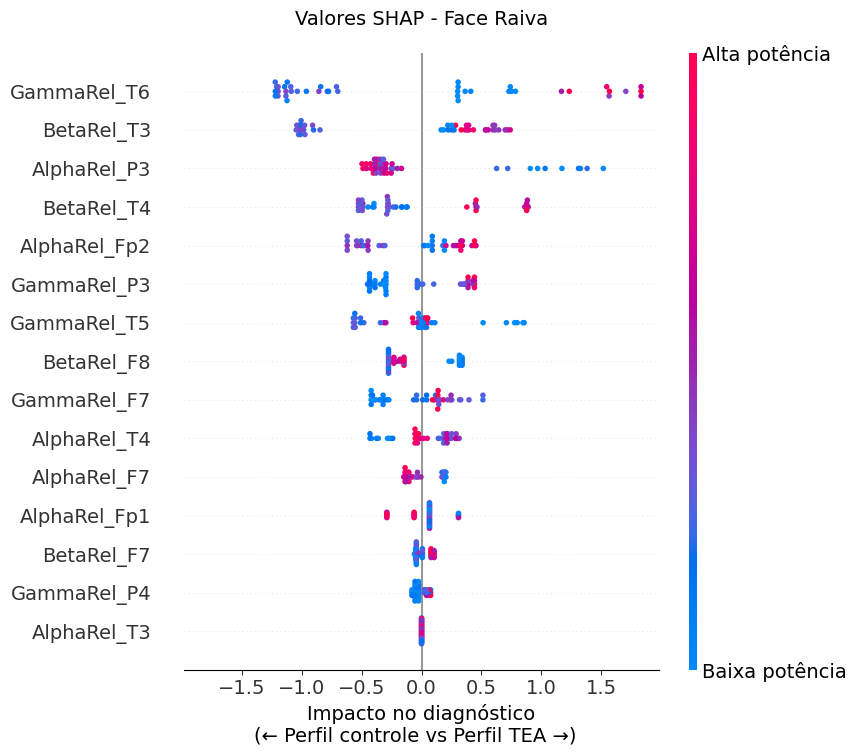


✅ Todas as imagens foram processadas.


In [3]:
# 03. VISUALIZAÇÃO: FEATURE IMPORTANCE E SHAP VALUES 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
import os
import warnings

try:
    import shap
except ImportError:
    print("⚠️ A biblioteca 'shap' não está instalada. Execute '!pip install shap' e rode novamente.")
    shap = None

warnings.filterwarnings("ignore")

print("⏳ Extraindo as regras biológicas do XGBoost para as 3 condições...")

# 1. Configurações Visuais Estritas
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'font.weight': 'normal',
    'axes.labelweight': 'normal',
    'axes.titleweight': 'normal',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

caminho_csv = '../reports/tabela_features_eeg_completa.csv'
df = pd.read_csv(caminho_csv)

# Dicionário com os nomes das condições e suas siglas para o título
condicoes = {
    'Face Feliz': 'FF',
    'Face Neutra': 'FN',
    'Face Raiva': 'FR'
}

SEED = 97

for nome_condicao, sigla in condicoes.items():
    print(f"\n" + "-"*60)
    print(f" PROCESSANDO: {nome_condicao.upper()}")
    print("-"*60)
    
    df_f = df[df['Condicao'] == nome_condicao].copy()
    if df_f.empty:
        print(f"Atenção: Sem dados para {nome_condicao}. Pulando...")
        continue
        
    df_f = df_f.groupby(['ID', 'Grupo']).mean(numeric_only=True).reset_index()
    
    y = df_f['Grupo'].apply(lambda x: 1 if 'TEA' in x else 0).values
    X_bruto = df_f.drop(columns=['ID', 'Grupo', 'Condicao', 'Tipo'], errors='ignore')

    # Pipeline de Pré-processamento
    imputer = SimpleImputer(strategy='mean')
    X_imp = imputer.fit_transform(X_bruto)

    scaler = RobustScaler()
    X_sca = scaler.fit_transform(X_imp)

    selector = SelectKBest(score_func=f_classif, k=15)
    X_sel = selector.fit_transform(X_sca, y)

    indices_selecionados = selector.get_support(indices=True)
    nomes_features = X_bruto.columns[indices_selecionados]

    # Treinamento Global
    xgb_modelo = XGBClassifier(
        n_estimators=150, 
        max_depth=3, 
        learning_rate=0.1, 
        eval_metric='logloss', 
        random_state=SEED
    )
    xgb_modelo.fit(X_sel, y)

    # 1 - FEATURE IMPORTANCE PLOTS
    importancias = xgb_modelo.feature_importances_
    df_imp = pd.DataFrame({
        'Variável': nomes_features,
        'Importância': importancias
    }).sort_values(by='Importância', ascending=False)

    fig1, ax1 = plt.subplots(figsize=(10, 6))
    ax1.set_axisbelow(True)

    sns.barplot(data=df_imp, x='Importância', y='Variável', palette='Blues_r', edgecolor='white', linewidth=1.5, ax=ax1)

    # Ajustes de título e legenda do Feature Importance
    ax1.set_title(f'Top 15 características - XGBoost ({sigla})', pad=15)
    ax1.set_xlabel('Score de importância', labelpad=10)
    ax1.set_ylabel('')

    ax1.grid(axis='x', linestyle='-', alpha=0.3, color='#B0B0B0')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_color('#DDDDDD')
    ax1.spines['bottom'].set_color('#DDDDDD')

    plt.tight_layout()
    os.makedirs('../reports/figures', exist_ok=True)
    caminho_fig3a = f'../reports/figures/fig03_feature_importance_{sigla.lower()}.png'
    plt.savefig(caminho_fig3a, dpi=300, bbox_inches='tight')
    plt.show()

    # 2 - SHAP VALUES (Solução Nativa via XGBoost)
    if shap is not None:
        fig2 = plt.figure(figsize=(10, 6))
        
        # 1. Extraímos o motor nativo do XGBoost
        booster = xgb_modelo.get_booster()
        
        # 2. Convertemos os dados para o formato nativo do XGBoost para cálculo
        dmatrix = xgb.DMatrix(X_sel, feature_names=list(nomes_features))
        
        # 3. O próprio XGBoost calcula os SHAP Values internamente.
        # O parâmetro pred_contribs=True retorna a matriz exata que o SHAP precisa.
        shap_contribs = booster.predict(dmatrix, pred_contribs=True)
        
        # O XGBoost devolve os SHAP values de cada feature + 1 coluna extra no final (valor base).
        # Removemos a última coluna (:-1) para ficar só com a influência das variáveis.
        shap_values_tea = shap_contribs[:, :-1]

        plt.title(f'Valores SHAP - {nome_condicao}', pad=20, fontsize=14)
        
        # 4. Usamos o SHAP apenas como "desenhista", passando a matriz que já calculamos
        shap.summary_plot(shap_values_tea, X_sel, feature_names=list(nomes_features), show=False)
        
        # Centralização do eixo x
        ax2 = plt.gca()
        limites_x = ax2.get_xlim()
        max_abs = max(abs(limites_x[0]), abs(limites_x[1]))
        ax2.set_xlim(-max_abs, max_abs) 
        
        ax2.set_xlabel('Impacto no diagnóstico\n(← Perfil controle vs Perfil TEA →)  ', fontsize=14, fontweight='normal')
        ax2.tick_params(axis='both', labelsize=14)
        
        # Ajuste dos rótulos do eixo Y (Colorbar)
        fig = plt.gcf()
        for ax in fig.axes:
            if ax != ax2: 
                ax.set_ylabel('') 
                ax.set_yticks([0, 1])
                ax.set_yticklabels(['Baixa potência', 'Alta potência'], fontsize=14, fontweight='normal')
                ax.tick_params(length=0) 
        
        # Salvamento da imagem
        caminho_fig3b = f'../reports/figures/fig04_shap_values_{sigla.lower()}.png'
        plt.savefig(caminho_fig3b, dpi=300, bbox_inches='tight')
        plt.show()

print("\n✅ Todas as imagens foram processadas.")

⏳ Gerando o painel Alpha/Gamma (1x2)...


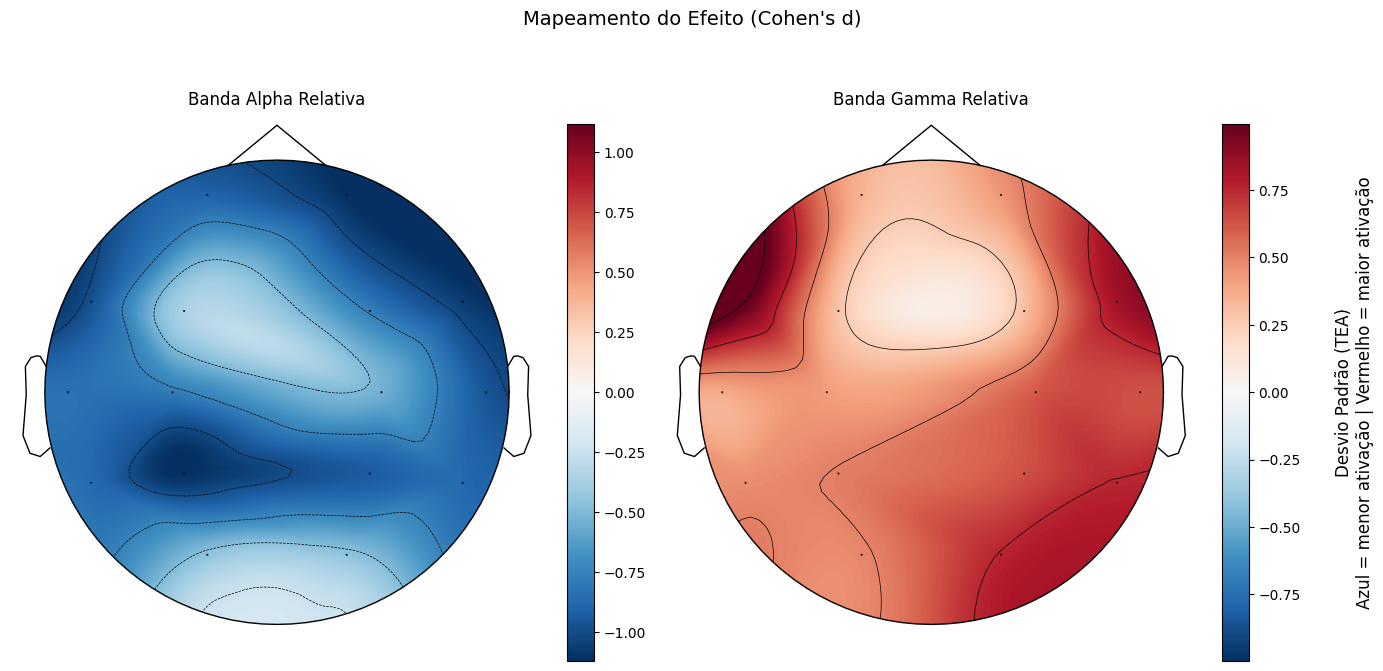

✅ Painel topográfico focado gerado e salvo em: ../reports/figures/fig05_painel_topografico_focado.png


In [16]:
# 04. VISUALIZAÇÃO: MAPA TOPOGRÁFICO DO TAMANHO DE EFEITO (COHEN'S D) - ALPHA E GAMMA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mne
import os
import warnings

# Configurações de segurança e silenciamento de avisos
warnings.filterwarnings("ignore")
mne.set_log_level('WARNING')

print("⏳ Gerando o painel Alpha/Gamma (1x2)...")

# 1. Configurações Visuais Estritas (Tamanho 12, Sem Negrito)
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'font.weight': 'normal',
    'axes.titleweight': 'normal',
    'figure.facecolor': 'white'
})

# 2. Geometria: Posições exatas dos 16 Canais
posicoes_manuais = {
    'Fp1': [-0.30, 0.85], 'Fp2': [ 0.30, 0.85],
    'F7':  [-0.80, 0.39], 'F3':  [-0.40, 0.35], 'F4':  [ 0.40, 0.35], 'F8':  [ 0.80, 0.39],
    'T3':  [-0.90, 0.00], 'C3':  [-0.45, 0.00], 'C4':  [ 0.45, 0.00], 'T4':  [ 0.90, 0.00],
    'T5':  [-0.80, -0.39], 'P3':  [-0.40, -0.35], 'P4':  [ 0.40, -0.35], 'T6':  [ 0.80, -0.39],
    'O1':  [-0.30, -0.70], 'O2':  [ 0.30, -0.70]
}
canais_reais = ['Fp1', 'Fp2', 'F7', 'F3', 'F4', 'F8', 'T3', 'C3', 'C4', 'T4', 'T5', 'P3', 'P4', 'T6', 'O1', 'O2']
pos_array = np.array([posicoes_manuais[ch] for ch in canais_reais])

# 3. Dados: Carregamento e Isolamento da Face Feliz (N=42)
caminho_csv = '../reports/tabela_features_eeg_completa.csv'
df = pd.read_csv(caminho_csv)

# Filtra a condição e garante a média por sujeito (N=42)
df_f = df[df['Condicao'] == 'Face Feliz'].copy()
df_f = df_f.groupby(['ID', 'Grupo']).mean(numeric_only=True).reset_index()

# Define os grupos
y = df_f['Grupo'].apply(lambda x: 1 if 'TEA' in x else 0).values

# 4. Preparação do Painel
metricas_alvo = ['AlphaRel', 'GammaRel']
titulos_metricas = ['Banda Alpha Relativa', 'Banda Gamma Relativa']

fig, axes = plt.subplots(1, 2, figsize=(14, 7)) # Ajuste de tamanho para 1x2
axes = axes.flatten()

# 5. Cálculo e Plotagem
for idx, metrica in enumerate(metricas_alvo):
    valores_efeito = []
    
    # Loop por canal para calcular o Cohen's d
    for ch in canais_reais:
        nome_coluna = f"{metrica}_{ch}"
        
        if nome_coluna in df_f.columns:
            data = df_f[nome_coluna]
            
            # Médias dos grupos
            mean_tea = data[y == 1].mean()
            mean_ctrl = data[y == 0].mean()
            
            # Desvio Padrão Combinado (Pooled Standard Deviation)
            n_tea, n_ctrl = sum(y == 1), sum(y == 0)
            var_tea, var_ctrl = data[y == 1].var(ddof=1), data[y == 0].var(ddof=1)
            std_pool = np.sqrt(((n_tea - 1) * var_tea + (n_ctrl - 1) * var_ctrl) / (n_tea + n_ctrl - 2))
            
            # Cohen's d: (TEA - Controle) / std_pool
            d = (mean_tea - mean_ctrl) / std_pool if std_pool > 0 else 0
            valores_efeito.append(d)
        else:
            valores_efeito.append(0.0) # Fallback para canal sem dado

    valores_efeito = np.array(valores_efeito)
    
    # Limite simétrico para o colormap (centralizado no zero)
    limit = np.max(np.abs(valores_efeito)) if np.max(np.abs(valores_efeito)) > 0 else 1

    # Plotagem topográfica usando a geometria manual
    resultado_plot = mne.viz.plot_topomap(valores_efeito,
                                          pos=pos_array,
                                          axes=axes[idx], show=False,
                                          cmap='RdBu_r', # Red-Blue reversed
                                          vlim=(-limit, limit),
                                          contours=4,
                                          sensors=True,
                                          outlines='head',
                                          sphere=1.0)

    # Captura o objeto da imagem para a colorbar
    im = resultado_plot[0] if isinstance(resultado_plot, tuple) else resultado_plot

    # Ajustes finos do eixo
    axes[idx].set_xlim(-1.15, 1.15)
    axes[idx].set_ylim(-1.15, 1.15)
    axes[idx].set_title(titulos_metricas[idx], fontsize=12, fontweight='normal', pad=15)

    # 6. Colobar e Legendas
    cbar = plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=10)
    
    # Texto da legenda
    if idx == 1: 
        cbar.set_label("Desvio Padrão (TEA)\nAzul = menor ativação | Vermelho = maior ativação", 
                       rotation=90, labelpad=25, fontsize=12, fontweight='normal')

# 7. Título e Salvamento
plt.suptitle("Mapeamento do Efeito (Cohen's d)", fontsize=14, fontweight='normal', y=1.02)
plt.tight_layout()

# Cria a pasta e salva a imagem em alta resolução
os.makedirs('../reports/figures', exist_ok=True)
caminho_painel = '../reports/figures/fig05_painel_topografico_focado.png'
plt.savefig(caminho_painel, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Painel topográfico focado gerado e salvo em: {caminho_painel}")

⏳ Gerando o painel topográfico 2x3 (Alpha e Gamma)...


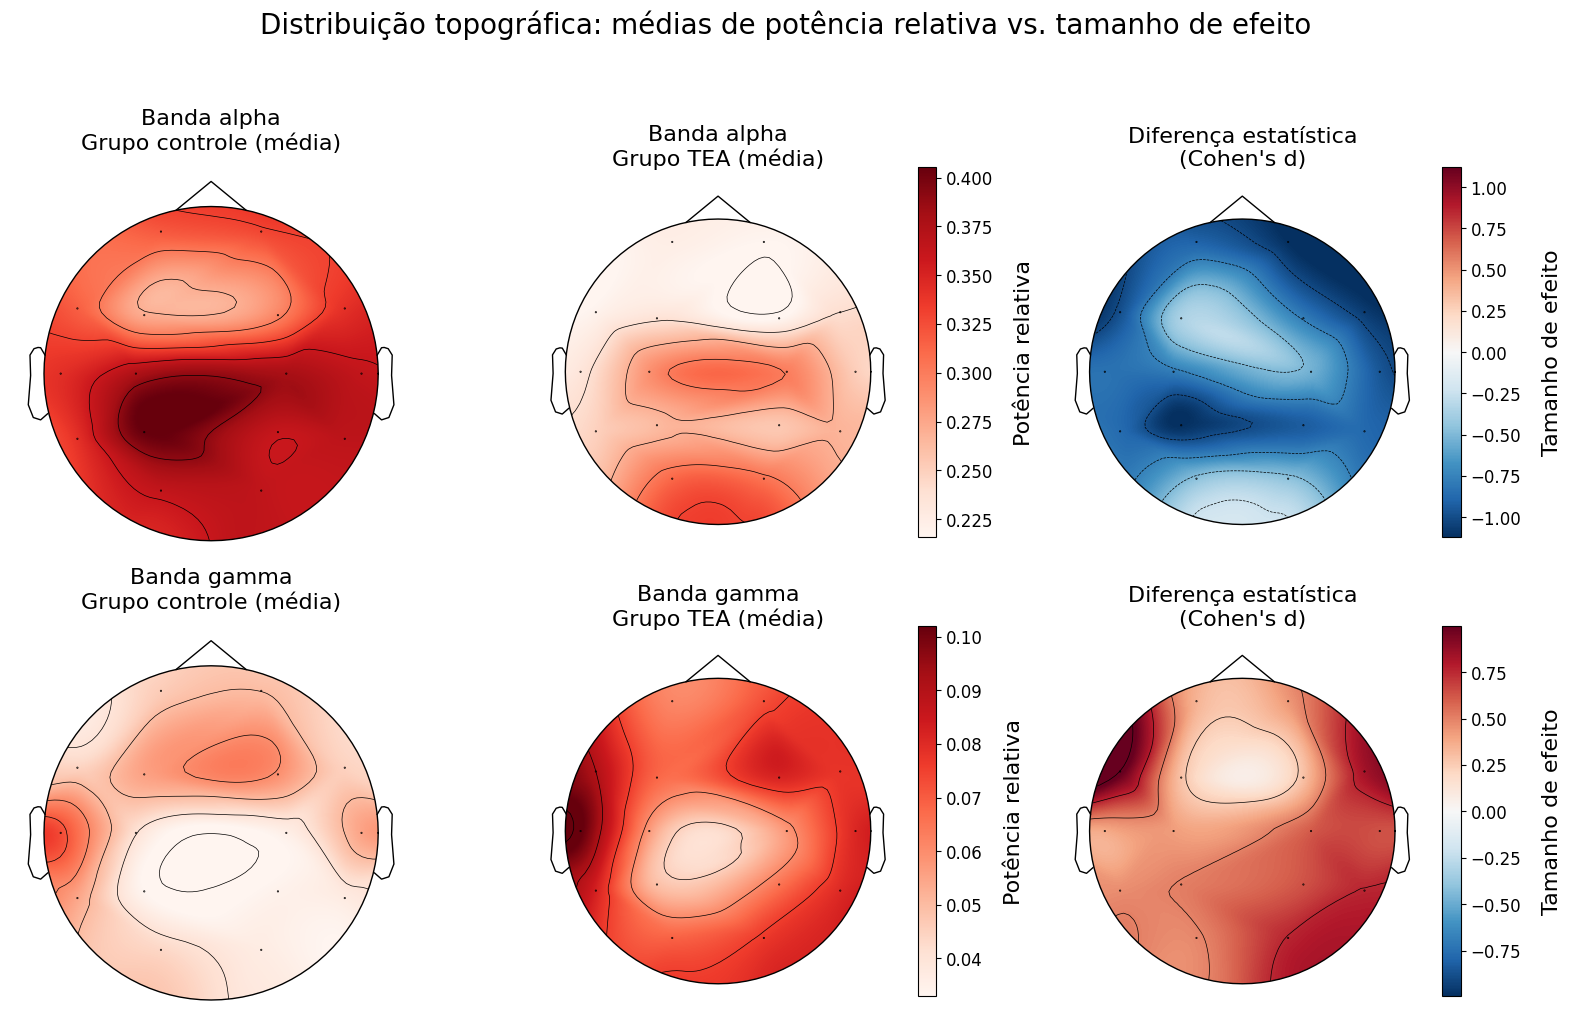

✅ Painel topográfico 2x3 gerado e salvo em: ../reports/figures/fig05_painel_topografico_grid.png


In [17]:
# 04. VISUALIZAÇÃO: PAINEL TOPOGRÁFICO COMPARATIVO (MÉDIAS VS COHEN'S D) - 2x3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mne
import os
import warnings

# Configurações de segurança e silenciamento de avisos
warnings.filterwarnings("ignore")
mne.set_log_level('WARNING')

print("⏳ Gerando o painel topográfico 2x3 (Alpha e Gamma)...")

# 1. Configurações Visuais Estritas
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'font.weight': 'normal',
    'axes.titleweight': 'normal',
    'figure.facecolor': 'white'
})

# 2. Geometria: Posições dos 16 Canais
posicoes_manuais = {
    'Fp1': [-0.30, 0.85], 'Fp2': [ 0.30, 0.85],
    'F7':  [-0.80, 0.39], 'F3':  [-0.40, 0.35], 'F4':  [ 0.40, 0.35], 'F8':  [ 0.80, 0.39],
    'T3':  [-0.90, 0.00], 'C3':  [-0.45, 0.00], 'C4':  [ 0.45, 0.00], 'T4':  [ 0.90, 0.00],
    'T5':  [-0.80, -0.39], 'P3':  [-0.40, -0.35], 'P4':  [ 0.40, -0.35], 'T6':  [ 0.80, -0.39],
    'O1':  [-0.30, -0.70], 'O2':  [ 0.30, -0.70]
}
canais_reais = ['Fp1', 'Fp2', 'F7', 'F3', 'F4', 'F8', 'T3', 'C3', 'C4', 'T4', 'T5', 'P3', 'P4', 'T6', 'O1', 'O2']
pos_array = np.array([posicoes_manuais[ch] for ch in canais_reais])

# 3. Dados: Carregamento e Isolamento da Face Feliz
caminho_csv = '../reports/tabela_features_eeg_completa.csv'
df = pd.read_csv(caminho_csv)

df_f = df[df['Condicao'] == 'Face Feliz'].copy()
df_f = df_f.groupby(['ID', 'Grupo']).mean(numeric_only=True).reset_index()

# Define os grupos matematicamente (TEA = 1, Controle = 0)
y = df_f['Grupo'].apply(lambda x: 1 if 'TEA' in x else 0).values

# 4. Preparação do Painel 2x3
metricas_alvo = ['AlphaRel', 'GammaRel']
nomes_bandas = ['Banda alpha', 'Banda gamma']

# Figura maior para acomodar as 6 topografias com folga
fig, axes = plt.subplots(2, 3, figsize=(16, 10)) 

# 5. Cálculo e Plotagem Iterativa
for row, metrica in enumerate(metricas_alvo):
    val_ctrl, val_tea, val_d = [], [], []
    
    # Extração de dados por canal
    for ch in canais_reais:
        nome_coluna = f"{metrica}_{ch}"
        
        if nome_coluna in df_f.columns:
            data = df_f[nome_coluna]
            
            # Médias absolutas para o mapa de ativação
            mean_tea = data[y == 1].mean()
            mean_ctrl = data[y == 0].mean()
            
            # Cohen's d (Desvio Padrão Combinado)
            n_tea, n_ctrl = sum(y == 1), sum(y == 0)
            var_tea, var_ctrl = data[y == 1].var(ddof=1), data[y == 0].var(ddof=1)
            std_pool = np.sqrt(((n_tea - 1) * var_tea + (n_ctrl - 1) * var_ctrl) / (n_tea + n_ctrl - 2))
            
            d = (mean_tea - mean_ctrl) / std_pool if std_pool > 0 else 0
            
            val_ctrl.append(mean_ctrl)
            val_tea.append(mean_tea)
            val_d.append(d)
        else:
            val_ctrl.append(0.0)
            val_tea.append(0.0)
            val_d.append(0.0)

    # Conversão para arrays numpy
    val_ctrl, val_tea, val_d = np.array(val_ctrl), np.array(val_tea), np.array(val_d)
    
    # Definição dos Limites de Cor (Vlim)
    # A escala de potência (Reds) precisa ser idêntica entre Controle e TEA na mesma linha
    vmax_pwr = max(np.max(val_ctrl), np.max(val_tea))
    vmin_pwr = min(np.min(val_ctrl), np.min(val_tea))
    
    # A escala do Cohen's d deve ser simétrica em torno do zero
    limit_d = np.max(np.abs(val_d)) if np.max(np.abs(val_d)) > 0 else 1

    # PLOT 1: CONTROLE 
    im_ctrl = mne.viz.plot_topomap(val_ctrl, pos=pos_array, axes=axes[row, 0], show=False, 
                                   cmap='Reds', vlim=(vmin_pwr, vmax_pwr), 
                                   contours=4, sensors=True, outlines='head', sphere=1.0)[0]
    axes[row, 0].set_title(f"{nomes_bandas[row]}\nGrupo controle (média)", pad=10)

    # PLOT 2: TEA
    im_tea = mne.viz.plot_topomap(val_tea, pos=pos_array, axes=axes[row, 1], show=False, 
                                  cmap='Reds', vlim=(vmin_pwr, vmax_pwr), 
                                  contours=4, sensors=True, outlines='head', sphere=1.0)[0]
    axes[row, 1].set_title(f"{nomes_bandas[row]}\nGrupo TEA (média)", pad=10)
    
    # Colorbar para a Potência (compartilhada entre Controle e TEA, ancorada no gráfico TEA)
    cbar_pwr = plt.colorbar(im_tea, ax=axes[row, 1], fraction=0.046, pad=0.04)
    cbar_pwr.set_label("Potência relativa", rotation=90, labelpad=15)

    # --- PLOT 3: COHEN'S D ---
    im_d = mne.viz.plot_topomap(val_d, pos=pos_array, axes=axes[row, 2], show=False, 
                                cmap='RdBu_r', vlim=(-limit_d, limit_d), 
                                contours=4, sensors=True, outlines='head', sphere=1.0)[0]
    axes[row, 2].set_title(f"Diferença estatística\n(Cohen's d)", pad=10)
    
    # Colorbar para o Cohen's d
    cbar_d = plt.colorbar(im_d, ax=axes[row, 2], fraction=0.046, pad=0.04)
    cbar_d.set_label("Tamanho de efeito", rotation=90, labelpad=15)

# 6. Título Global e Salvamento
plt.suptitle("Distribuição topográfica: médias de potência relativa vs. tamanho de efeito", fontsize=20, y=1.02)
plt.tight_layout()

# Cria a pasta e salva a imagem
os.makedirs('../reports/figures', exist_ok=True)
caminho_painel = '../reports/figures/fig05_painel_topografico_grid.png'
plt.savefig(caminho_painel, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Painel topográfico 2x3 gerado e salvo em: {caminho_painel}")

⏳ Estruturando distribuições biológicas brutas (Violin Plots)...


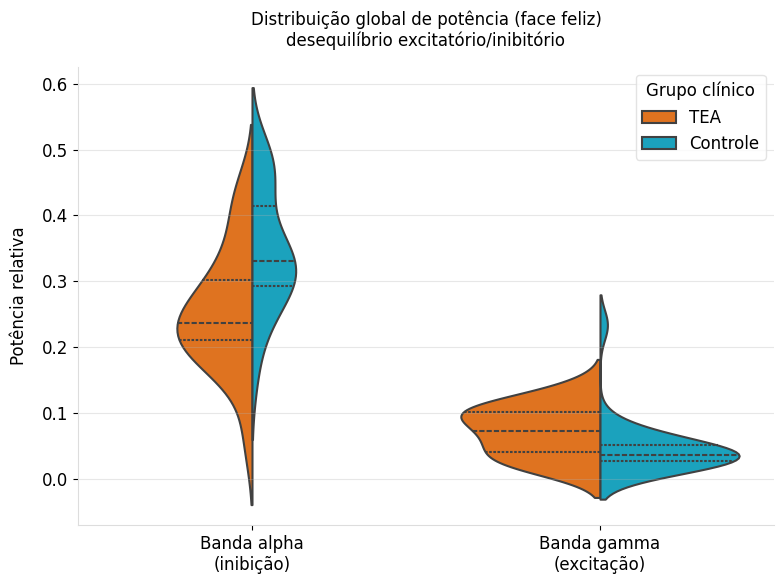

✅ Violin plot gerado e salvo em: ../reports/figures/fig07_violinos_biomarcadores.png
ok


In [ ]:
# 05. VISUALIZAÇÃO: VIOLIN PLOT (ALPHA E GAMMA)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")

print("⏳ Estruturando distribuições biológicas brutas (Violin Plots)...")

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'font.weight': 'normal',
    'axes.labelweight': 'normal',
    'axes.titleweight': 'normal',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

caminho_csv = '../reports/tabela_features_eeg_completa.csv'
df = pd.read_csv(caminho_csv)

df_f = df[df['Condicao'] == 'Face Feliz'].copy()
df_f = df_f.groupby(['ID', 'Grupo']).mean(numeric_only=True).reset_index()

# 1. Calculando a Média Global (Cérebro Inteiro) para Alpha e Gamma
colunas_alpha = [c for c in df_f.columns if 'AlphaRel' in c]
colunas_gamma = [c for c in df_f.columns if 'GammaRel' in c]

df_f['Alpha_Global'] = df_f[colunas_alpha].mean(axis=1)
df_f['Gamma_Global'] = df_f[colunas_gamma].mean(axis=1)

# 2. Reorganizando os dados (Melt) para o Seaborn entender a divisão
df_plot = df_f[['Grupo', 'Alpha_Global', 'Gamma_Global']].copy()
# Padronizando o nome dos grupos para a legenda
df_plot['Grupo'] = df_plot['Grupo'].apply(lambda x: 'TEA' if 'TEA' in x else 'Controle')

df_melt = pd.melt(df_plot, id_vars=['Grupo'], value_vars=['Alpha_Global', 'Gamma_Global'],
                  var_name='Banda', value_name='Potência relativa (média global)')

# Traduzindo os nomes das bandas para o eixo
df_melt['Banda'] = df_melt['Banda'].replace({'Alpha_Global': 'Banda alpha\n(inibição)', 
                                             'Gamma_Global': 'Banda gamma\n(excitação)'})

# 3. Plotagem do Violino
fig, ax = plt.subplots(figsize=(8, 6))

# Paleta
paleta = {
    'Controle': '#00B4D8',   # Turquesa vibrante
    'TEA': '#FF6F00'         # Laranja forte
}

# O split=True cola as metades dos violinos
sns.violinplot(data=df_melt, x='Banda', y='Potência relativa (média global)', hue='Grupo',
               split=True, inner="quartile", palette=paleta, linewidth=1.5, ax=ax)

ax.set_title("Distribuição global de potência (face feliz)\ndesequilíbrio excitatório/inibitório", pad=15)
ax.set_xlabel('')
ax.set_ylabel('Potência relativa', labelpad=10)

ax.grid(axis='y', linestyle='-', alpha=0.3, color='#B0B0B0')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#DDDDDD')
ax.spines['bottom'].set_color('#DDDDDD')

# Ajusta a legenda
plt.legend(title='Grupo clínico', loc='upper right', frameon=True, edgecolor='#DDDDDD')
plt.tight_layout()

os.makedirs('../reports/figures', exist_ok=True)
caminho_violino = '../reports/figures/fig07_violinos_biomarcadores.png'
plt.savefig(caminho_violino, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Violin plot gerado e salvo em: {caminho_violino}")

⏳ Estruturando distribuições biológicas brutas (Violin Plots)...


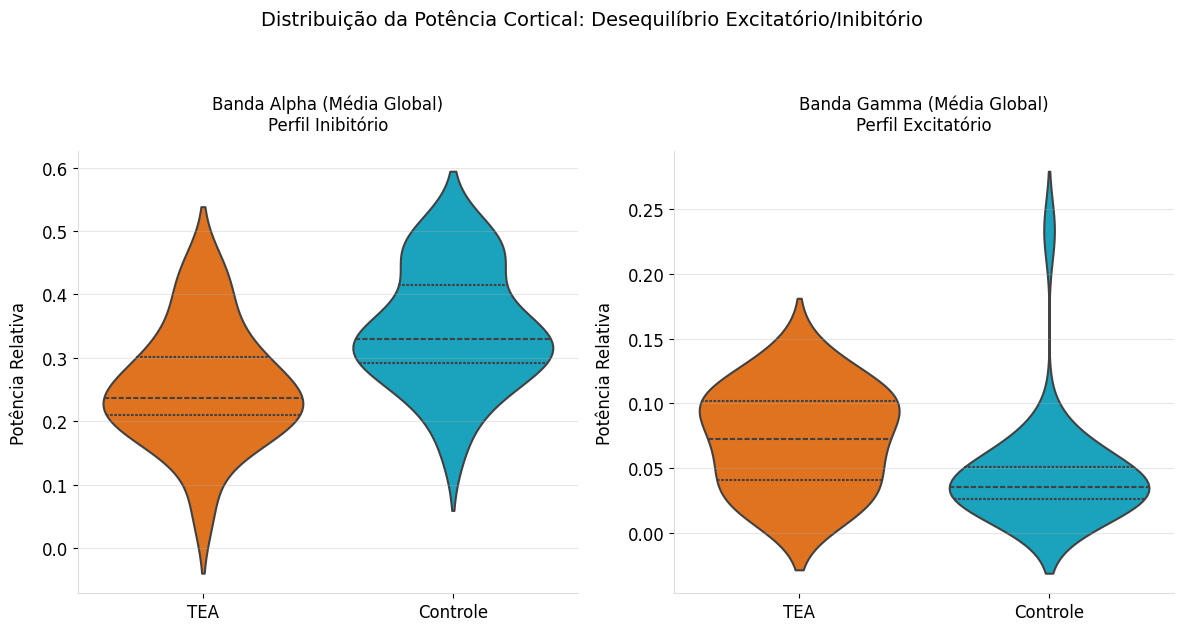

✅ Painel de Violin Plots gerado e salvo em: ../reports/figures/fig07_violinos_biomarcadores.png


In [ ]:
# 05. VISUALIZAÇÃO: VIOLIN PLOT (ALPHA E GAMMA) - PAINEL 1x2

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")

print("⏳ Estruturando distribuições biológicas brutas (Violin Plots)...")

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'font.weight': 'normal',
    'axes.labelweight': 'normal',
    'axes.titleweight': 'normal',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

caminho_csv = '../reports/tabela_features_eeg_completa.csv'
df = pd.read_csv(caminho_csv)

df_f = df[df['Condicao'] == 'Face Feliz'].copy()
df_f = df_f.groupby(['ID', 'Grupo']).mean(numeric_only=True).reset_index()

# 1. Calculando a Média Global (Cérebro Inteiro) para Alpha e Gamma
# NOTA: Se preferir focar na região fronto-temporal para o Gamma, 
# você pode alterar 'colunas_gamma' para selecionar apenas canais como F3, F4, F7, F8, T3, T4.
colunas_alpha = [c for c in df_f.columns if 'AlphaRel' in c]
colunas_gamma = [c for c in df_f.columns if 'GammaRel' in c]

df_f['Alpha_Global'] = df_f[colunas_alpha].mean(axis=1)
df_f['Gamma_Global'] = df_f[colunas_gamma].mean(axis=1)

# Padronizando o nome dos grupos
df_f['Grupo'] = df_f['Grupo'].apply(lambda x: 'TEA' if 'TEA' in x else 'Controle')

# Paleta
paleta = {
    'Controle': '#00B4D8',   # Turquesa
    'TEA': '#FF6F00'         # Laranja
}

# 2. Configuração do Painel 1x2 (Eixos Y independentes)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --- Subplot 1: Banda Alpha ---
sns.violinplot(data=df_f, x='Grupo', y='Alpha_Global', palette=paleta, 
               inner="quartile", linewidth=1.5, ax=axes[0])
axes[0].set_title("Banda Alpha (Média Global)\nPerfil Inibitório", pad=15)
axes[0].set_ylabel("Potência Relativa", labelpad=10)
axes[0].set_xlabel("")

# --- Subplot 2: Banda Gamma ---
sns.violinplot(data=df_f, x='Grupo', y='Gamma_Global', palette=paleta, 
               inner="quartile", linewidth=1.5, ax=axes[1])
axes[1].set_title("Banda Gamma (Média Global)\nPerfil Excitatório", pad=15)
axes[1].set_ylabel("Potência Relativa", labelpad=10)
axes[1].set_xlabel("")

# 3. Limpeza estética e Salvamento
for ax in axes:
    ax.grid(axis='y', linestyle='-', alpha=0.3, color='#B0B0B0')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#DDDDDD')
    ax.spines['bottom'].set_color('#DDDDDD')

plt.suptitle("Distribuição da Potência Cortical: Desequilíbrio Excitatório/Inibitório", fontsize=14, y=1.05)
plt.tight_layout()

os.makedirs('../reports/figures', exist_ok=True)
caminho_violino = '../reports/figures/fig07_violinos_biomarcadores.png'
plt.savefig(caminho_violino, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Painel de Violin Plots gerado e salvo em: {caminho_violino}")

✅ Matriz de Confusão gerada e salva em: ../reports/figures/fig01_confusion_matrix_rf.png


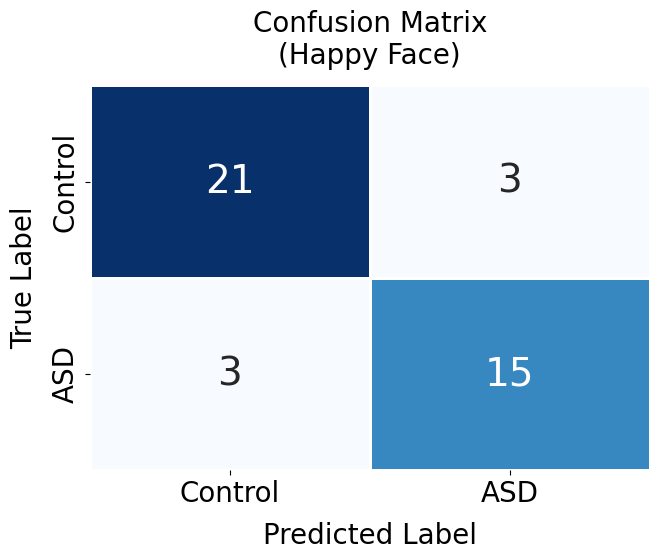

In [2]:
# 01. VISUALIZAÇÃO: MATRIZ DE CONFUSÃO (RANDOM FOREST 5-FOLD CV)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix
import warnings
import os

warnings.filterwarnings("ignore")

# 1. Configurações Visuais
plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'font.weight': 'normal',
    'axes.labelweight': 'normal',
    'axes.titleweight': 'normal'
})

# 2. Carregamento e Filtragem (Apenas Face Feliz)
caminho_csv = '../reports/tabela_features_eeg_completa.csv'
df = pd.read_csv(caminho_csv)

df_f = df[df['Condicao'] == 'Face Feliz'].copy()
df_f = df_f.groupby(['ID', 'Grupo']).mean(numeric_only=True).reset_index()

y = df_f['Grupo'].apply(lambda x: 1 if 'TEA' in x else 0).values

# 5 Variáveis de Ouro
features_ouro = ['AlphaRel_P3', 'AlphaRel_Fp2', 'BetaRel_F7', 'AlphaRel_F8', 'GammaRel_F7']
X = df_f[features_ouro].values

# 3. Pipeline final (StandardScaler + Random Forest)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42))
])

# Validação Rigorosa
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=23)

# 4. Preparação do Plot
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('white')

# Predição com 5-Fold CV
y_pred = cross_val_predict(pipeline, X, y, cv=cv_strategy)
cm = confusion_matrix(y, y_pred)

# Plotagem
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['Control', 'ASD'], yticklabels=['Control', 'ASD'],
            annot_kws={"size": 28, "weight": "normal"}, 
            linewidths=2, linecolor='white')

ax.set_title('Confusion Matrix\n(Happy Face)', pad=15)
ax.set_ylabel('True Label', labelpad=10)
ax.set_xlabel('Predicted Label', labelpad=10)

plt.tight_layout()

os.makedirs('../reports/figures', exist_ok=True)
caminho_imagem = '../reports/figures/fig01_confusion_matrix_rf.png'
plt.savefig(caminho_imagem, dpi=300, bbox_inches='tight')
print(f"✅ Matriz de Confusão gerada e salva em: {caminho_imagem}")
plt.show()

✅ Feature Importance gerada e salva em: ../reports/figures/fig02_feature_importance_rf.png


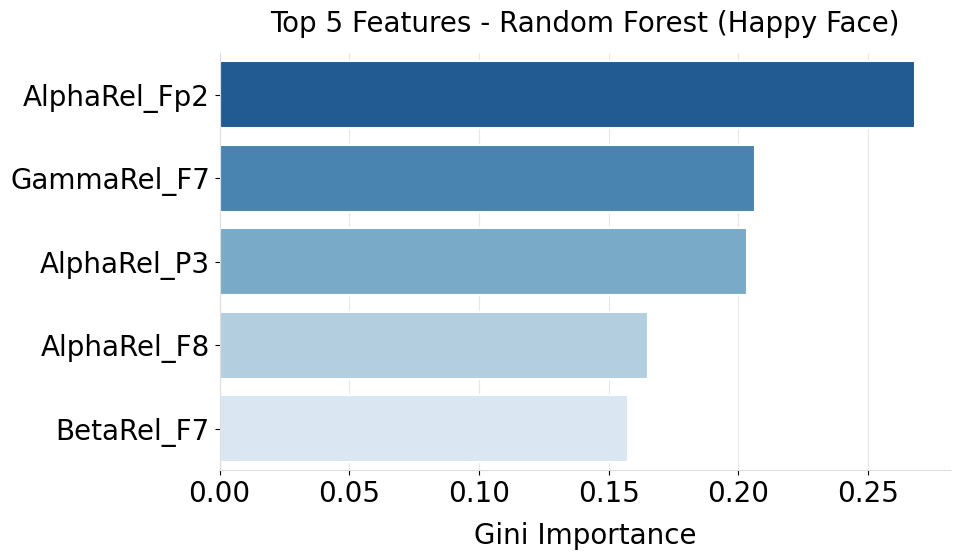

In [3]:
# 02. VISUALIZAÇÃO: FEATURE IMPORTANCE (RANDOM FOREST)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import warnings
import os

warnings.filterwarnings("ignore")

# 1. Configurações Visuais 
plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'font.weight': 'normal',
    'axes.labelweight': 'normal',
    'axes.titleweight': 'normal',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

# 2. Carregamento de Dados
caminho_csv = '../reports/tabela_features_eeg_completa.csv'
df = pd.read_csv(caminho_csv)

df_f = df[df['Condicao'] == 'Face Feliz'].copy()
df_f = df_f.groupby(['ID', 'Grupo']).mean(numeric_only=True).reset_index()

y = df_f['Grupo'].apply(lambda x: 1 if 'TEA' in x else 0).values
features_ouro = ['AlphaRel_P3', 'AlphaRel_Fp2', 'BetaRel_F7', 'AlphaRel_F8', 'GammaRel_F7']
X_sel = df_f[features_ouro]

# Treinamento do Random Forest Base
rf_modelo = RandomForestClassifier(random_state=42)
rf_modelo.fit(X_sel, y)

# 3. Extração (Gini Importance)
importancias = rf_modelo.feature_importances_
df_imp = pd.DataFrame({
    'Feature': features_ouro,
    'Importance': importancias
}).sort_values(by='Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_axisbelow(True)

sns.barplot(data=df_imp, x='Importance', y='Feature', palette='Blues_r', edgecolor='white', linewidth=1.5, ax=ax)

# Ajustes de título e legenda
ax.set_title('Top 5 Features - Random Forest (Happy Face)', pad=15)
ax.set_xlabel('Gini Importance', labelpad=10)
ax.set_ylabel('')

ax.grid(axis='x', linestyle='-', alpha=0.3, color='#B0B0B0')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#DDDDDD')
ax.spines['bottom'].set_color('#DDDDDD')

plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
caminho_imagem = '../reports/figures/fig02_feature_importance_rf.png'
plt.savefig(caminho_imagem, dpi=300, bbox_inches='tight')
print(f"✅ Feature Importance gerada e salva em: {caminho_imagem}")
plt.show()

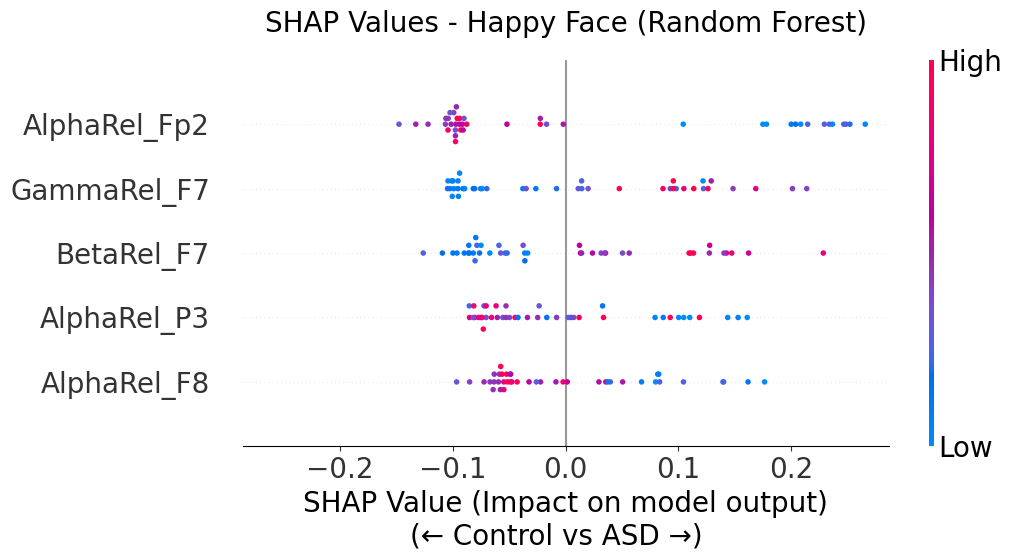

✅ SHAP Values gerados e salvos em: ../reports/figures/fig03_shap_values_rf.png


In [6]:
# 03. VISUALIZAÇÃO: SHAP VALUES (RANDOM FOREST) - AJUSTE FINO DE ESPAÇAMENTO

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import os
import warnings

try:
    import shap
except ImportError:
    print("⚠️ A biblioteca 'shap' não está instalada. Execute '!pip install shap' e rode novamente.")
    shap = None

warnings.filterwarnings("ignore")

# 1. Configurações Visuais
plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'font.weight': 'normal',
    'axes.labelweight': 'normal',
    'axes.titleweight': 'normal',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

# 2. Carregamento de Dados
caminho_csv = '../reports/tabela_features_eeg_completa.csv'
df = pd.read_csv(caminho_csv)

df_f = df[df['Condicao'] == 'Face Feliz'].copy()
df_f = df_f.groupby(['ID', 'Grupo']).mean(numeric_only=True).reset_index()

y = df_f['Grupo'].apply(lambda x: 1 if 'TEA' in x else 0).values
features_ouro = ['AlphaRel_P3', 'AlphaRel_Fp2', 'BetaRel_F7', 'AlphaRel_F8', 'GammaRel_F7']
X_sel = df_f[features_ouro]

# Treinamento
rf_modelo = RandomForestClassifier(random_state=42)
rf_modelo.fit(X_sel, y)

# 3. SHAP Values
if shap is not None:
    # AJUSTE 1: Proporção (Largura, Altura) da figura base
    fig = plt.figure(figsize=(11, 6))
    
    explainer = shap.TreeExplainer(rf_modelo)
    shap_values = explainer.shap_values(X_sel)
    
    if isinstance(shap_values, list):
        shap_values_tea = shap_values[1]
    elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
        shap_values_tea = shap_values[:, :, 1]
    else:
        shap_values_tea = shap_values

    plt.title('SHAP Values - Happy Face (Random Forest)', pad=20, fontsize=20)
    
    # AJUSTE 2: O parâmetro plot_size=(Largura, Altura) força o SHAP a respeitar a proporção
    shap.summary_plot(shap_values_tea, X_sel, feature_names=features_ouro, show=False, plot_size=(11, 6))
    
    # Centralização do eixo x
    ax = plt.gca()
    limites_x = ax.get_xlim()
    max_abs = max(abs(limites_x[0]), abs(limites_x[1]))
    ax.set_xlim(-max_abs, max_abs) 
    
    ax.set_xlabel('SHAP Value (Impact on model output)\n(← Control vs ASD →)  ', fontsize=20, fontweight='normal')
    ax.tick_params(axis='both', labelsize=20)
    
    # Ajuste dos rótulos do eixo Y (Colorbar)
    fig = plt.gcf()
    for eixo in fig.axes:
        if eixo != ax: 
            eixo.set_ylabel('') 
            eixo.set_yticks([0, 1])
            eixo.set_yticklabels(['Low', 'High'], fontsize=20, fontweight='normal')
            eixo.tick_params(length=0) 
    
    plt.tight_layout()
    os.makedirs('../reports/figures', exist_ok=True)
    caminho_fig = '../reports/figures/fig03_shap_values_rf.png'
    plt.savefig(caminho_fig, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ SHAP Values gerados e salvos em: {caminho_fig}")

✅ Distribuição de Métricas gerada e salva em: ../reports/figures/fig01_cv_metrics_distribution.png


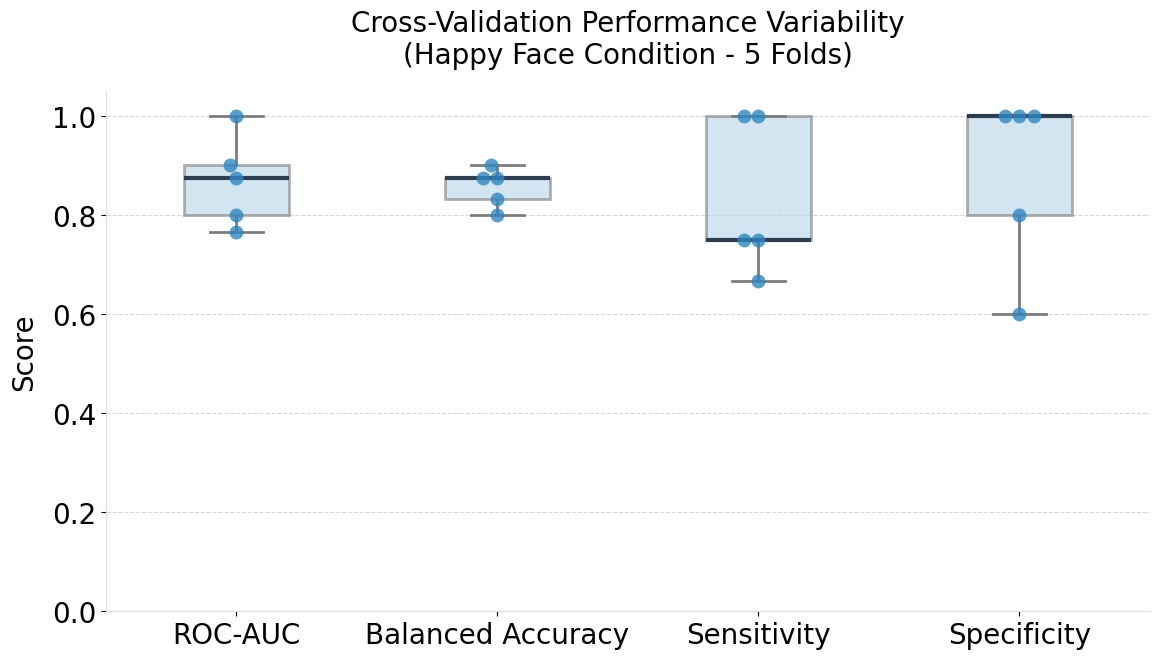


Mean Performance ± Standard Deviation:
ROC-AUC: 0.8683 ± 0.0817
Balanced Accuracy: 0.8567 ± 0.0355
Sensitivity: 0.8333 ± 0.1394
Specificity: 0.8800 ± 0.1600


In [3]:
# 01. VISUALIZAÇÃO: CROSS-VALIDATION PERFORMANCE VARIABILITY

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, recall_score, confusion_matrix
import warnings
import os

warnings.filterwarnings("ignore")

# 1. Configurações Visuais
plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'font.weight': 'normal',
    'axes.labelweight': 'normal',
    'axes.titleweight': 'normal',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

# 2. Carregamento e Filtragem (Apenas Face Feliz)
caminho_csv = '../reports/tabela_features_eeg_completa.csv'
df = pd.read_csv(caminho_csv)

df_f = df[df['Condicao'] == 'Face Feliz'].copy()
df_f = df_f.groupby(['ID', 'Grupo']).mean(numeric_only=True).reset_index()

y = df_f['Grupo'].apply(lambda x: 1 if 'TEA' in x else 0).values

# 5 Variáveis Selecionadas a Priori
features_ouro = ['AlphaRel_P3', 'AlphaRel_Fp2', 'BetaRel_F7', 'AlphaRel_F8', 'GammaRel_F7']
X = df_f[features_ouro].values

# 3. Extração Rigorosa de Métricas (5-Fold CV)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=23)
rf_modelo = RandomForestClassifier(random_state=42)
scaler = StandardScaler()

# Nomenclatura com padronização correta (Title Case)
resultados = {
    'ROC-AUC': [],
    'Balanced Accuracy': [],
    'Sensitivity': [],
    'Specificity': []
}

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Transformação estrita no fold (Leakage-free)
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    rf_modelo.fit(X_train_scaled, y_train)
    y_pred = rf_modelo.predict(X_test_scaled)
    y_proba = rf_modelo.predict_proba(X_test_scaled)[:, 1]
    
    # Cálculos das métricas
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    
    resultados['ROC-AUC'].append(roc_auc_score(y_test, y_proba))
    resultados['Balanced Accuracy'].append(balanced_accuracy_score(y_test, y_pred))
    resultados['Sensitivity'].append(recall_score(y_test, y_pred)) # TPR
    resultados['Specificity'].append(tn / (tn + fp)) # TNR

# Formatação em DataFrame para o Seaborn
df_metricas = pd.DataFrame(resultados)
df_melted = df_metricas.melt(var_name='Metric', value_name='Score')

# 4. Preparação do Plot
fig, ax = plt.subplots(figsize=(12, 7))

# Boxplot com linha da mediana destacada
sns.boxplot(data=df_melted, x='Metric', y='Score', 
            color='#AED6F1', width=0.4, linewidth=2, 
            boxprops=dict(alpha=0.6), 
            medianprops=dict(color='#2C3E50', linewidth=3), # Mediana mais escura e grossa
            showfliers=False, ax=ax)

# Swarmplot para espalhar os pontos sem sobreposição vertical
sns.swarmplot(data=df_melted, x='Metric', y='Score', 
              color='#2E86C1', size=10, alpha=0.8, ax=ax)

# Ajustes de Eixos e Títulos com padrão gramatical inglês acadêmico
ax.set_ylim(0.0, 1.05)
ax.set_title('Cross-Validation Performance Variability\n(Happy Face Condition - 5 Folds)', pad=20)
ax.set_ylabel('Score', labelpad=10)
ax.set_xlabel('')

# Estética limpa
ax.grid(axis='y', linestyle='--', alpha=0.5, color='#B0B0B0')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#DDDDDD')
ax.spines['bottom'].set_color('#DDDDDD')

plt.tight_layout()

# 5. Salvamento
os.makedirs('../reports/figures', exist_ok=True)
caminho_imagem = '../reports/figures/fig01_cv_metrics_distribution.png'
plt.savefig(caminho_imagem, dpi=300, bbox_inches='tight')
print(f"✅ Distribuição de Métricas gerada e salva em: {caminho_imagem}")
plt.show()

# Exibição de texto para relatório
print("\nMean Performance ± Standard Deviation:")
for metrica in resultados.keys():
    media = np.mean(resultados[metrica])
    std = np.std(resultados[metrica])
    print(f"{metrica}: {media:.4f} ± {std:.4f}")

✅ Matriz de Confusão e Curva ROC geradas e salvas em: ../reports/figures/fig02_classification_evaluation.png


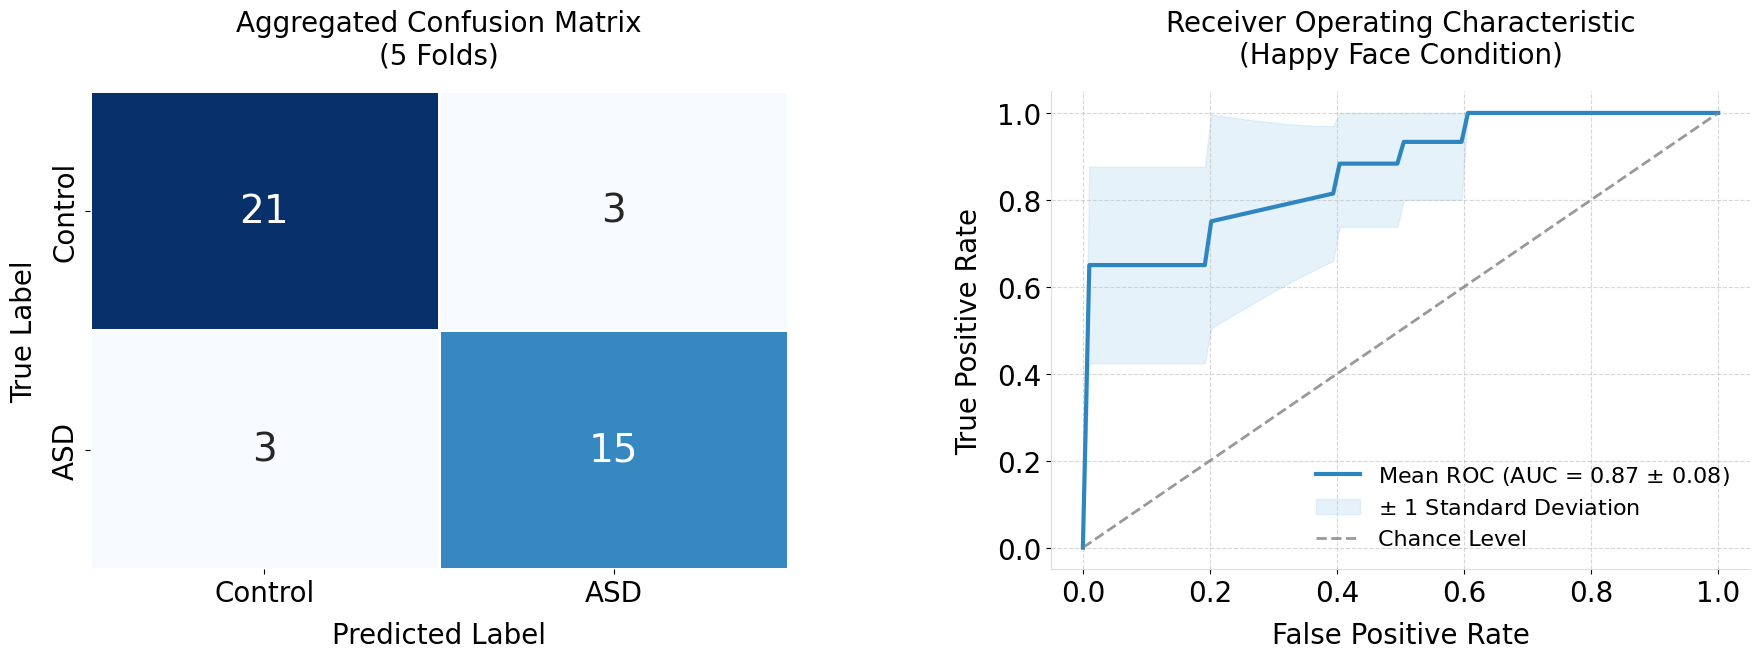

In [4]:
# 02. VISUALIZAÇÃO: CLASSIFICATION EVALUATION (CM + MEAN ROC CURVE)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, auc
import warnings
import os

warnings.filterwarnings("ignore")

# 1. Configurações Visuais
plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'font.weight': 'normal',
    'axes.labelweight': 'normal',
    'axes.titleweight': 'normal',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

# 2. Carregamento e Filtragem (Apenas Face Feliz)
caminho_csv = '../reports/tabela_features_eeg_completa.csv'
df = pd.read_csv(caminho_csv)

df_f = df[df['Condicao'] == 'Face Feliz'].copy()
df_f = df_f.groupby(['ID', 'Grupo']).mean(numeric_only=True).reset_index()

y = df_f['Grupo'].apply(lambda x: 1 if 'TEA' in x else 0).values

# 5 Variáveis Selecionadas a Priori
features_ouro = ['AlphaRel_P3', 'AlphaRel_Fp2', 'BetaRel_F7', 'AlphaRel_F8', 'GammaRel_F7']
X = df_f[features_ouro].values

# 3. Treinamento Rigoroso e Extração para ROC/CM
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=23)
rf_modelo = RandomForestClassifier(random_state=42)
scaler = StandardScaler()

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)
y_pred_all = []
y_true_all = []

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Transformação estrita no fold (Leakage-free)
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    rf_modelo.fit(X_train_scaled, y_train)
    y_proba = rf_modelo.predict_proba(X_test_scaled)[:, 1]
    y_pred = rf_modelo.predict(X_test_scaled)
    
    # Armazenamento para a Matriz de Confusão Agregada
    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)
    
    # Cálculos para a Curva ROC do fold atual
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    
    # Interpolação para padronizar o eixo X (FPR) e poder calcular a média da curva
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

# 4. Preparação do Plot (1 linha, 2 colunas)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- PLOT 1: Matriz de Confusão Agregada ---
cm = confusion_matrix(y_true_all, y_pred_all)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Control', 'ASD'], yticklabels=['Control', 'ASD'],
            annot_kws={"size": 28, "weight": "normal"}, 
            linewidths=2, linecolor='white')

axes[0].set_title('Aggregated Confusion Matrix\n(5 Folds)', pad=20)
axes[0].set_ylabel('True Label', labelpad=10)
axes[0].set_xlabel('Predicted Label', labelpad=10)

# --- PLOT 2: Mean ROC Curve ---
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

# Sombreamento do Desvio Padrão
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

axes[1].plot(mean_fpr, mean_tpr, color='#2E86C1', linewidth=3,
             label=f'Mean ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})')
axes[1].fill_between(mean_fpr, tprs_lower, tprs_upper, color='#AED6F1', alpha=0.3,
                     label=r'$\pm$ 1 Standard Deviation')

# Linha de Chance (50%)
axes[1].plot([0, 1], [0, 1], linestyle='--', lw=2, color='gray', label='Chance Level', alpha=0.8)

# Ajustes de Eixos e Títulos da Curva ROC
axes[1].set_xlim([-0.05, 1.05])
axes[1].set_ylim([-0.05, 1.05])
axes[1].set_xlabel('False Positive Rate', labelpad=10)
axes[1].set_ylabel('True Positive Rate', labelpad=10)
axes[1].set_title('Receiver Operating Characteristic\n(Happy Face Condition)', pad=20)
axes[1].legend(loc="lower right", fontsize=16, frameon=False)

axes[1].grid(axis='both', linestyle='--', alpha=0.5, color='#B0B0B0')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_color('#DDDDDD')
axes[1].spines['bottom'].set_color('#DDDDDD')

plt.tight_layout(w_pad=6.0)

# 5. Salvamento
os.makedirs('../reports/figures', exist_ok=True)
caminho_imagem = '../reports/figures/fig02_classification_evaluation.png'
plt.savefig(caminho_imagem, dpi=300, bbox_inches='tight')
print(f"✅ Matriz de Confusão e Curva ROC geradas e salvas em: {caminho_imagem}")
plt.show()

Valor Máximo de Cohen's d encontrado (deve ser diferente de 0): 1.1208


✅ Topomaps de Tamanho de Efeito gerados e salvos em: ../reports/figures/fig03_cohens_d_topomaps.png


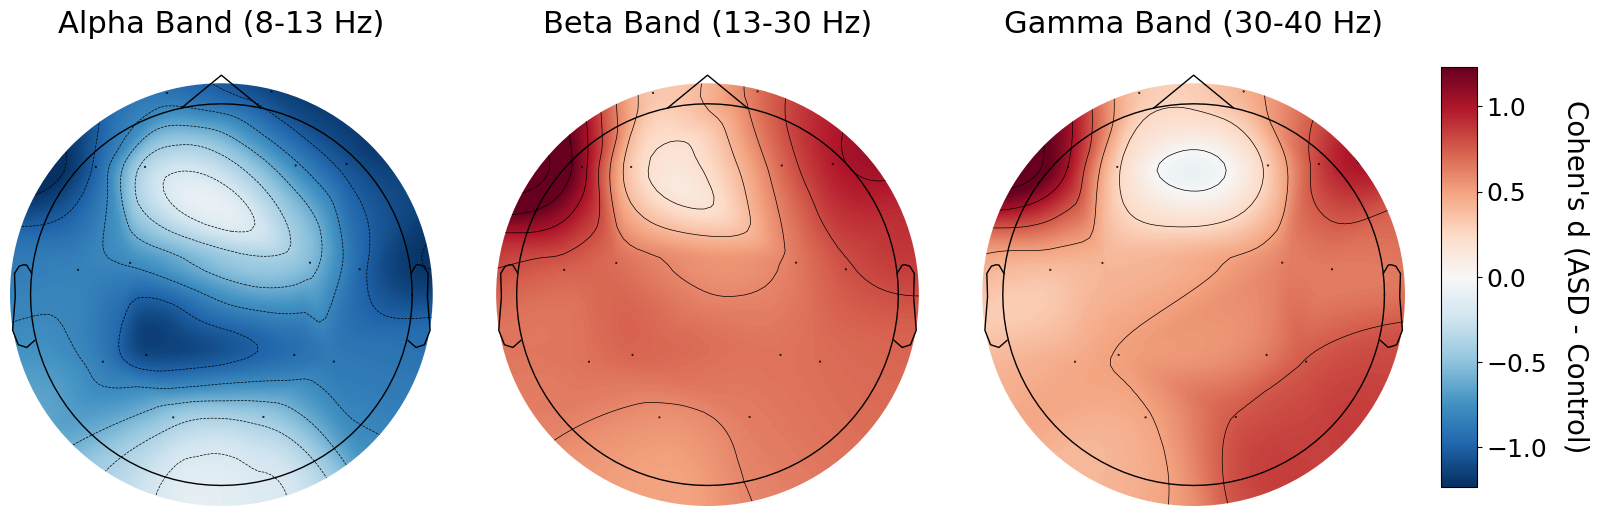

In [11]:
# 03. VISUALIZAÇÃO: GROUP-LEVEL EEG DIFFERENCES (COHEN'S D TOPOMAPS)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings

try:
    import mne
except ImportError:
    print("⚠️ A biblioteca 'mne' não está instalada. Execute '!pip install mne' e rode novamente.")
    mne = None

warnings.filterwarnings("ignore")

# 1. Configurações Visuais
plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 22,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'font.weight': 'normal',
    'axes.titleweight': 'normal',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

# 2. Função de cálculo (Cohen's d)
def calcular_cohens_d(grupo1, grupo2):
    g1 = pd.to_numeric(grupo1, errors='coerce').dropna()
    g2 = pd.to_numeric(grupo2, errors='coerce').dropna()
    
    # Proteção caso o canal esteja vazio
    if len(g1) < 2 or len(g2) < 2:
        return 0.0  
        
    n1, n2 = len(g1), len(g2)
    var1, var2 = np.var(g1, ddof=1), np.var(g2, ddof=1)
    
    s_pooled = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    d = (np.mean(g1) - np.mean(g2)) / s_pooled
    return d

# 3. Carregamento e Isolamento Garantido dos Grupos (Apenas Face Feliz)
caminho_csv = '../reports/tabela_features_eeg_completa.csv'
df = pd.read_csv(caminho_csv)

df_f = df[df['Condicao'] == 'Face Feliz'].copy()
df_f = df_f.groupby(['ID', 'Grupo']).mean(numeric_only=True).reset_index()

# Garantia absoluta da divisão: usando o mesmo vetor y do Machine Learning
y = df_f['Grupo'].apply(lambda x: 1 if 'TEA' in x else 0).values

df_tea = df_f[y == 1]
df_ctrl = df_f[y == 0]

# 4. Definição das Bandas e Extração dos Canais Disponíveis
bandas = ['Alpha', 'Beta', 'Gamma']
titulos = ['Alpha Band (8-13 Hz)', 'Beta Band (13-30 Hz)', 'Gamma Band (30-40 Hz)']

canais = [col.split('_')[1] for col in df_f.columns if col.startswith('AlphaRel_')]

if mne is not None:
    # Estrutura MNE Padrão 10-20
    info = mne.create_info(ch_names=canais, sfreq=1000, ch_types='eeg')
    montage = mne.channels.make_standard_montage('standard_1020')
    info.set_montage(montage)

    d_values_por_banda = []
    max_d_abs = 0  

    for banda in bandas:
        d_vals = []
        for canal in canais:
            feature_name = f'{banda}Rel_{canal}'
            d = calcular_cohens_d(df_tea[feature_name], df_ctrl[feature_name])
            d_vals.append(d)
        
        d_values_por_banda.append(np.array(d_vals))
        max_d_abs = max(max_d_abs, np.max(np.abs(d_vals)))

    print(f"Valor Máximo de Cohen's d encontrado (deve ser diferente de 0): {max_d_abs:.4f}")

    # 5. Preparação do Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    vmax = max_d_abs * 1.1 
    vmin = -vmax
    
    # Trava de segurança (não deve mais ser ativada)
    if vmax == 0: 
        vmax, vmin = 1.0, -1.0

    for idx, (banda, ax, d_vals, titulo) in enumerate(zip(bandas, axes, d_values_por_banda, titulos)):
        # Contido estritamente na cabeça (extrapolate='head') e interpolando as cores
        im, _ = mne.viz.plot_topomap(d_vals, info, axes=ax, show=False, 
                                     cmap='RdBu_r', vlim=(vmin, vmax),
                                     extrapolate='head', contours=6)
        ax.set_title(titulo, pad=15)

    # 6. Colorbar Unificada
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) 
    cbar = plt.colorbar(im, cax=cbar_ax)
    cbar.set_label("Cohen's d (ASD - Control)", rotation=270, labelpad=30, fontsize=20)
    cbar.ax.tick_params(labelsize=18)

    plt.subplots_adjust(wspace=0.15, right=0.9)

    # 7. Salvamento
    os.makedirs('../reports/figures', exist_ok=True)
    caminho_imagem = '../reports/figures/fig03_cohens_d_topomaps.png'
    plt.savefig(caminho_imagem, dpi=300, bbox_inches='tight')
    print(f"✅ Topomaps de Tamanho de Efeito gerados e salvos em: {caminho_imagem}")
    plt.show()

✅ Painel 3x3 de Topomaps gerado e salvo em: ../reports/figures/fig03_comprehensive_topomaps_3x3.png


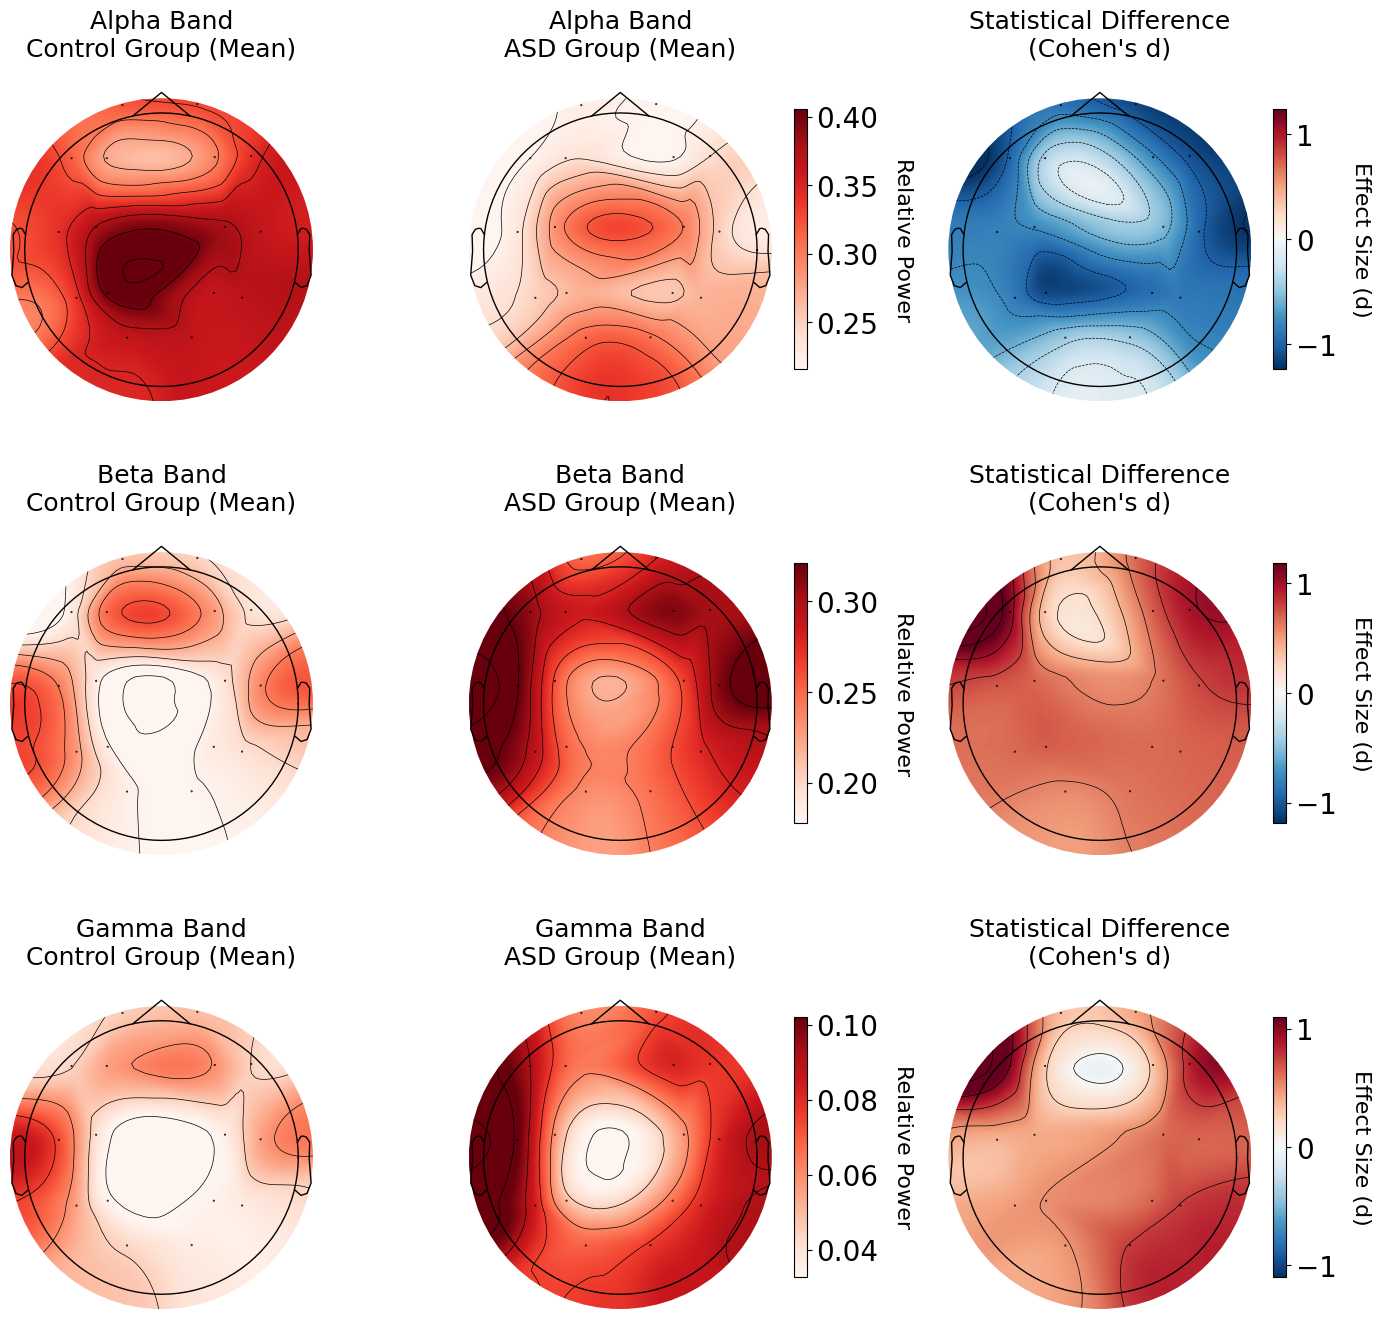

In [13]:
# 03. VISUALIZAÇÃO ALTERNATIVA: COMPREHENSIVE EEG DIFFERENCES (3x3 GRID)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings

try:
    import mne
except ImportError:
    print("⚠️ A biblioteca 'mne' não está instalada. Execute '!pip install mne' e rode novamente.")
    mne = None

warnings.filterwarnings("ignore")

# 1. Configurações Visuais
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'font.weight': 'normal',
    'axes.titleweight': 'normal',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

# 2. Função de cálculo do Cohen's d (Segura contra NaNs)
def calcular_cohens_d(grupo1, grupo2):
    g1 = pd.to_numeric(grupo1, errors='coerce').dropna()
    g2 = pd.to_numeric(grupo2, errors='coerce').dropna()
    
    if len(g1) < 2 or len(g2) < 2:
        return 0.0  
        
    n1, n2 = len(g1), len(g2)
    var1, var2 = np.var(g1, ddof=1), np.var(g2, ddof=1)
    
    s_pooled = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    d = (np.mean(g1) - np.mean(g2)) / s_pooled
    return d

# Função para calcular média segura contra NaNs
def calcular_media_segura(grupo):
    g = pd.to_numeric(grupo, errors='coerce').dropna()
    return np.mean(g) if len(g) > 0 else 0.0

# 3. Carregamento e Isolamento (Apenas Face Feliz)
caminho_csv = '../reports/tabela_features_eeg_completa.csv'
df = pd.read_csv(caminho_csv)

df_f = df[df['Condicao'] == 'Face Feliz'].copy()
df_f = df_f.groupby(['ID', 'Grupo']).mean(numeric_only=True).reset_index()

y = df_f['Grupo'].apply(lambda x: 1 if 'TEA' in x else 0).values

df_tea = df_f[y == 1]
df_ctrl = df_f[y == 0]

# 4. Configuração das Bandas
bandas = ['Alpha', 'Beta', 'Gamma']
canais = [col.split('_')[1] for col in df_f.columns if col.startswith('AlphaRel_')]

if mne is not None:
    # Estrutura MNE Padrão 10-20
    info = mne.create_info(ch_names=canais, sfreq=1000, ch_types='eeg')
    montage = mne.channels.make_standard_montage('standard_1020')
    info.set_montage(montage)

    # 5. Preparação da Grade de Plotagem (3 linhas x 3 colunas)
    fig, axes = plt.subplots(3, 3, figsize=(18, 16))
    
    for i, banda in enumerate(bandas):
        medias_ctrl = []
        medias_tea = []
        d_vals = []
        
        # Extração dos dados por canal para a banda atual
        for canal in canais:
            feature_name = f'{banda}Rel_{canal}'
            
            m_ctrl = calcular_media_segura(df_ctrl[feature_name])
            m_tea = calcular_media_segura(df_tea[feature_name])
            d = calcular_cohens_d(df_tea[feature_name], df_ctrl[feature_name])
            
            medias_ctrl.append(m_ctrl)
            medias_tea.append(m_tea)
            d_vals.append(d)
            
        medias_ctrl = np.array(medias_ctrl)
        medias_tea = np.array(medias_tea)
        d_vals = np.array(d_vals)
        
        # Escala compartilhada de Potência Relativa (mínimo e máximo entre ambos os grupos)
        vmin_pwr = min(np.min(medias_ctrl), np.min(medias_tea))
        vmax_pwr = max(np.max(medias_ctrl), np.max(medias_tea))
        
        # Escala simétrica para o Cohen's d divergente
        vmax_d = np.max(np.abs(d_vals)) * 1.1
        vmin_d = -vmax_d if vmax_d > 0 else -1.0
        vmax_d = vmax_d if vmax_d > 0 else 1.0

        # --- COLUNA 1: Grupo Controle (Média) ---
        im_ctrl, _ = mne.viz.plot_topomap(medias_ctrl, info, axes=axes[i, 0], show=False, 
                                          cmap='Reds', vlim=(vmin_pwr, vmax_pwr),
                                          extrapolate='head', contours=6)
        axes[i, 0].set_title(f'{banda} Band\nControl Group (Mean)', pad=15)

        # --- COLUNA 2: Grupo TEA (Média) ---
        im_tea, _ = mne.viz.plot_topomap(medias_tea, info, axes=axes[i, 1], show=False, 
                                         cmap='Reds', vlim=(vmin_pwr, vmax_pwr),
                                         extrapolate='head', contours=6)
        axes[i, 1].set_title(f'{banda} Band\nASD Group (Mean)', pad=15)
        
        # Barra de Cores para a Potência Relativa (Ao lado da Coluna 2)
        cbar1 = fig.colorbar(im_tea, ax=axes[i, 1], shrink=0.8, pad=0.05)
        cbar1.set_label('Relative Power', rotation=270, labelpad=25)

        # --- COLUNA 3: Diferença Estatística (Cohen's d) ---
        im_d, _ = mne.viz.plot_topomap(d_vals, info, axes=axes[i, 2], show=False, 
                                       cmap='RdBu_r', vlim=(vmin_d, vmax_d),
                                       extrapolate='head', contours=6)
        axes[i, 2].set_title(f'Statistical Difference\n(Cohen\'s d)', pad=15)
        
        # Barra de Cores para o Cohen's d (Ao lado da Coluna 3)
        cbar2 = fig.colorbar(im_d, ax=axes[i, 2], shrink=0.8, pad=0.05)
        cbar2.set_label('Effect Size (d)', rotation=270, labelpad=25)

    # Ajustes finais de espaçamento da grade
    plt.subplots_adjust(hspace=0.4, wspace=0.1)

    # 6. Salvamento
    os.makedirs('../reports/figures', exist_ok=True)
    caminho_imagem = '../reports/figures/fig03_comprehensive_topomaps_3x3.png'
    plt.savefig(caminho_imagem, dpi=300, bbox_inches='tight')
    print(f"✅ Painel 3x3 de Topomaps gerado e salvo em: {caminho_imagem}")
    plt.show()

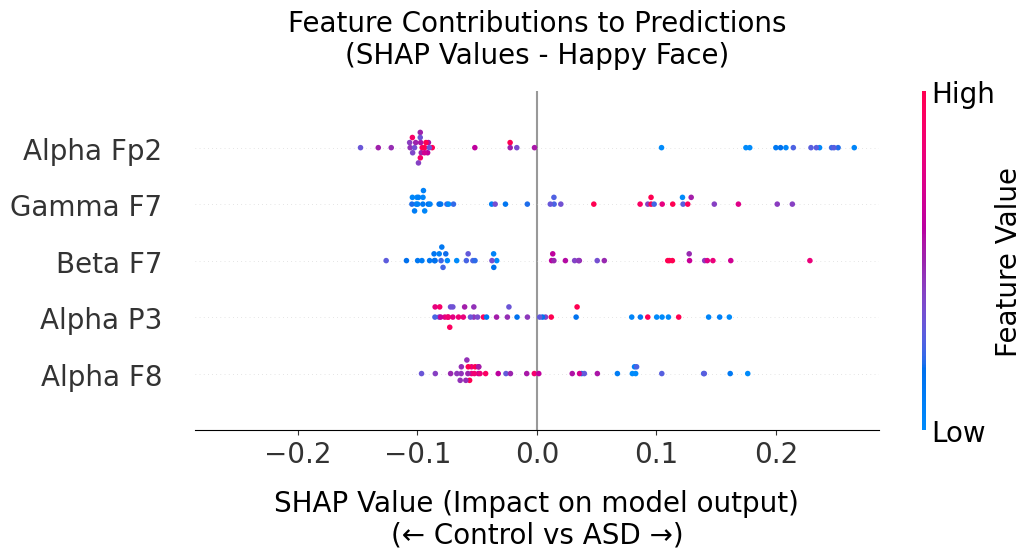

✅ SHAP Values com nomenclatura polida gerados e salvos em: ../reports/figures/fig04_shap_summary.png


In [12]:
# 04. VISUALIZAÇÃO: EXPLAINABILITY (SHAP SUMMARY PLOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import os
import warnings

try:
    import shap
except ImportError:
    print("⚠️ A biblioteca 'shap' não está instalada. Execute '!pip install shap' e rode novamente.")
    shap = None

warnings.filterwarnings("ignore")

# 1. Configurações Visuais (Forçando 'normal' em tudo)
plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'font.weight': 'normal',
    'axes.labelweight': 'normal',
    'axes.titleweight': 'normal', 
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

# 2. Carregamento e Filtragem (Apenas Face Feliz)
caminho_csv = '../reports/tabela_features_eeg_completa.csv'
df = pd.read_csv(caminho_csv)

df_f = df[df['Condicao'] == 'Face Feliz'].copy()
df_f = df_f.groupby(['ID', 'Grupo']).mean(numeric_only=True).reset_index()

y = df_f['Grupo'].apply(lambda x: 1 if 'TEA' in x else 0).values

# 5 Variáveis Selecionadas a Priori (Como o modelo lê)
features_ouro = ['AlphaRel_P3', 'AlphaRel_Fp2', 'BetaRel_F7', 'AlphaRel_F8', 'GammaRel_F7']
X_sel = df_f[features_ouro]

# LIMPEZA DE NOMES: Trocando 'AlphaRel_P3' por 'Alpha P3' (Como o humano lê)
nomes_limpos = [nome.replace('Rel_', ' ') for nome in features_ouro]

# 3. Treinamento Base
rf_modelo = RandomForestClassifier(random_state=42)
rf_modelo.fit(X_sel, y)

# 4. SHAP Values
if shap is not None:
    # Proporção equilibrada para 5 variáveis
    fig = plt.figure(figsize=(11, 6))
    
    explainer = shap.TreeExplainer(rf_modelo)
    shap_values = explainer.shap_values(X_sel)
    
    # Tratamento de compatibilidade de versão do SHAP
    if isinstance(shap_values, list):
        shap_values_tea = shap_values[1]
    elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
        shap_values_tea = shap_values[:, :, 1]
    else:
        shap_values_tea = shap_values

    # Injetando a lista de 'nomes_limpos' no argumento feature_names
    shap.summary_plot(shap_values_tea, X_sel, feature_names=nomes_limpos, show=False, plot_size=(11, 6))
    
    # Customização do Título e Eixos
    plt.title('Feature Contributions to Predictions\n(SHAP Values - Happy Face)', pad=20, fontsize=20, fontweight='normal')
    
    ax = plt.gca()
    
    # Centralização do eixo x (0 no meio do gráfico)
    limites_x = ax.get_xlim()
    max_abs = max(abs(limites_x[0]), abs(limites_x[1]))
    ax.set_xlim(-max_abs, max_abs) 
    
    ax.set_xlabel('SHAP Value (Impact on model output)\n(← Control vs ASD →)', fontsize=20, fontweight='normal', labelpad=15)
    ax.tick_params(axis='both', labelsize=20)
    
    # Ajuste da Barra de Cores (Feature Value)
    fig = plt.gcf()
    for eixo in fig.axes:
        if eixo != ax: 
            eixo.set_ylabel('Feature Value', fontsize=20, fontweight='normal') 
            eixo.set_yticks([0, 1])
            eixo.set_yticklabels(['Low', 'High'], fontsize=20, fontweight='normal')
            eixo.tick_params(length=0) 
    
    plt.tight_layout()
    os.makedirs('../reports/figures', exist_ok=True)
    caminho_fig = '../reports/figures/fig04_shap_summary.png'
    plt.savefig(caminho_fig, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ SHAP Values com nomenclatura polida gerados e salvos em: {caminho_fig}")

📊 RESULTADOS DA AUDITORIA ESTATÍSTICA:
--------------------------------------------------
[Alpha Fp2] Teste: Mann-Whitney | p-value: 0.0006
[Gamma F7] Teste: Mann-Whitney | p-value: 0.0012
[Beta F7] Teste: Mann-Whitney | p-value: 0.0022
[Alpha P3] Teste: T-test | p-value: 0.0008
[Alpha F8] Teste: T-test | p-value: 0.0019


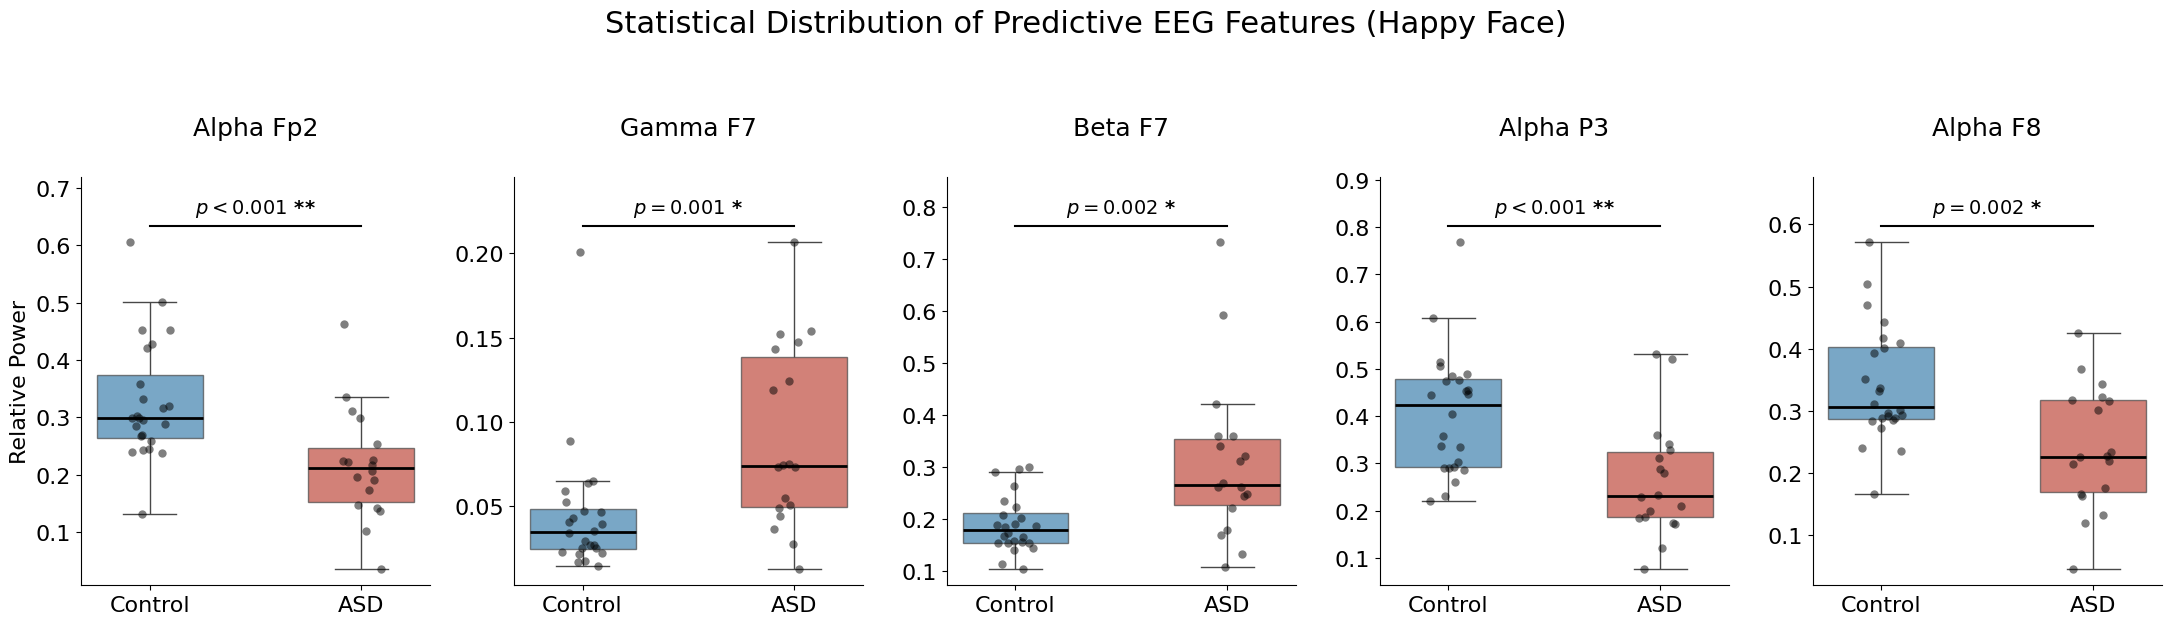

--------------------------------------------------
✅ Boxplots Estatísticos gerados e salvos em: ../reports/figures/figS1_features_distribution.png


In [4]:
# 05. EXPLORAÇÃO SUPLEMENTAR (S1): STATISTICAL DISTRIBUTION OF GOLDEN FEATURES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings

warnings.filterwarnings("ignore")

# 1. Configurações Visuais (Estilo acadêmico e limpo)
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'font.weight': 'normal',
    'axes.labelweight': 'normal',
    'axes.titleweight': 'normal',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

# 2. Carregamento e Preparação dos Dados
caminho_csv = '../reports/tabela_features_eeg_completa.csv'
df = pd.read_csv(caminho_csv)

df_f = df[df['Condicao'] == 'Face Feliz'].copy()
df_f = df_f.groupby(['ID', 'Grupo']).mean(numeric_only=True).reset_index()

# Padronizando a nomenclatura dos grupos para o Plot
df_f['Grupo_Plot'] = df_f['Grupo'].apply(lambda x: 'ASD' if 'TEA' in x else 'Control')

# As 5 Features de Ouro do seu modelo
features_ouro = ['AlphaRel_Fp2', 'GammaRel_F7', 'BetaRel_F7', 'AlphaRel_P3', 'AlphaRel_F8']
nomes_limpos = ['Alpha Fp2', 'Gamma F7', 'Beta F7', 'Alpha P3', 'Alpha F8']

# 3. Preparação do Plot (1 Linha, 5 Colunas)
fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.suptitle('Statistical Distribution of Predictive EEG Features (Happy Face)', fontsize=22, y=1.05)

# Paleta inspirada nos artigos clássicos: Controle (Azul), TEA (Vermelho/Rosa)
paleta = {'Control': '#2E86C1', 'ASD': "#D43B2A"}

print("📊 RESULTADOS DA AUDITORIA ESTATÍSTICA:\n" + "-"*50)

for ax, feature, nome_limpo in zip(axes, features_ouro, nomes_limpos):
    # Isolando os grupos e removendo NaNs por segurança
    g_ctrl = df_f[df_f['Grupo_Plot'] == 'Control'][feature].dropna()
    g_asd = df_f[df_f['Grupo_Plot'] == 'ASD'][feature].dropna()
    
    # --- TESTE DE NORMALIDADE (Shapiro-Wilk) ---
    _, p_shapiro_ctrl = stats.shapiro(g_ctrl)
    _, p_shapiro_asd = stats.shapiro(g_asd)
    
    # --- ÁRVORE DE DECISÃO ESTATÍSTICA ---
    if p_shapiro_ctrl > 0.05 and p_shapiro_asd > 0.05:
        # Ambos normais -> Teste T (assumindo variâncias desiguais por segurança: Welch's t-test)
        stat, p_val = stats.ttest_ind(g_ctrl, g_asd, equal_var=False)
        nome_teste = "T-test"
    else:
        # Pelo menos um não-normal -> Mann-Whitney U
        stat, p_val = stats.mannwhitneyu(g_ctrl, g_asd, alternative='two-sided')
        nome_teste = "Mann-Whitney"
        
    print(f"[{nome_limpo}] Teste: {nome_teste} | p-value: {p_val:.4f}")

    # --- PLOTAGEM DO BOXPLOT + PONTOS INDIVIDUAIS ---
    sns.boxplot(data=df_f, x='Grupo_Plot', y=feature, order=['Control', 'ASD'],
                palette=paleta, ax=ax, width=0.5, showfliers=False, 
                boxprops=dict(alpha=0.7), medianprops=dict(color='black', linewidth=2))
    
    sns.stripplot(data=df_f, x='Grupo_Plot', y=feature, order=['Control', 'ASD'],
                  color='black', size=6, alpha=0.5, jitter=True, ax=ax)
    
    # Ajustes estéticos de cada eixo
    ax.set_title(nome_limpo, pad=30)
    ax.set_xlabel('')
    if ax == axes[0]:
        ax.set_ylabel('Relative Power')
    else:
        ax.set_ylabel('')
        
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # --- ANOTAÇÃO DO VALOR P NO GRÁFICO ---
    # Encontrar a altura máxima do plot para colocar o texto do p-value
    y_max = df_f[feature].max()
    y_range = y_max - df_f[feature].min()
    y_text = y_max + (y_range * 0.05)
    
    # Formatação do texto: se p < 0.05 adiciona asterisco, senao deixa só o valor
    if p_val < 0.001:
        p_text = "$p < 0.001$ **"
        font_weight = 'bold'
    elif p_val < 0.05:
        p_text = f"$p = {p_val:.3f}$ *"
        font_weight = 'bold'
    else:
        p_text = f"$p = {p_val:.3f}$"
        font_weight = 'normal'
        
    # Desenhando a linha e o texto
    ax.plot([0, 1], [y_text, y_text], color='black', lw=1.5)
    ax.text(0.5, y_text + (y_range * 0.02), p_text, ha='center', va='bottom', 
            fontsize=14, fontweight=font_weight)
    
    # Ajustar o limite do y para o texto não cortar
    ax.set_ylim(df_f[feature].min() - (y_range*0.05), y_text + (y_range * 0.15))

plt.tight_layout()

# 4. Salvamento
os.makedirs('../reports/figures', exist_ok=True)
caminho_fig = '../reports/figures/figS1_features_distribution.png'
plt.savefig(caminho_fig, dpi=300, bbox_inches='tight')
plt.show()

print("-" * 50)
print(f"✅ Boxplots Estatísticos gerados e salvos em: {caminho_fig}")

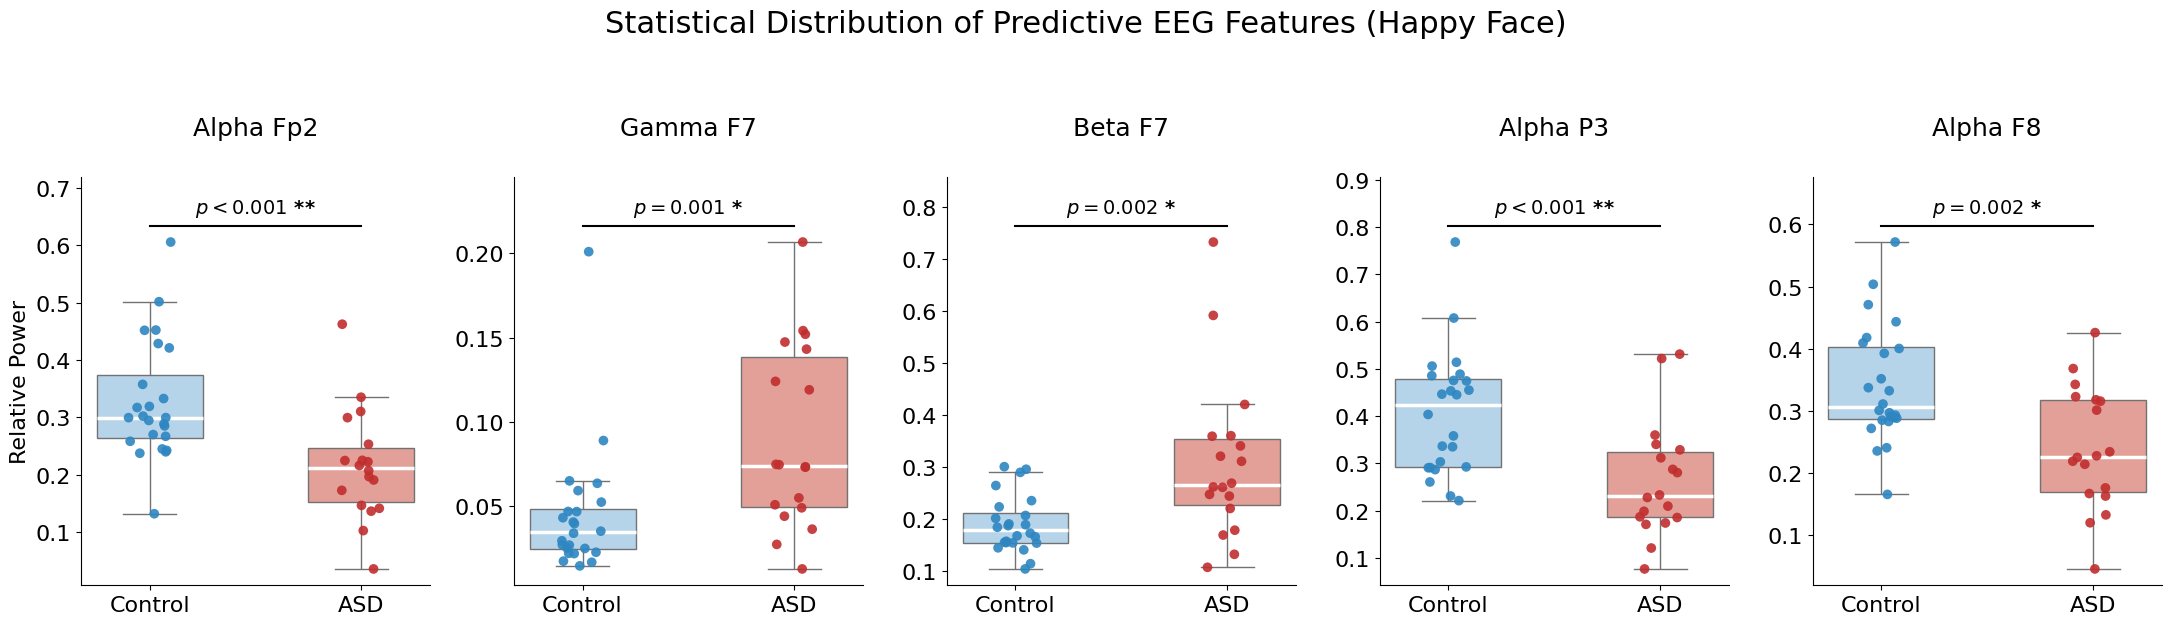

✅ Boxplots esteticamente ajustados gerados com sucesso!


In [6]:
# 05. EXPLORAÇÃO SUPLEMENTAR (S1): STATISTICAL DISTRIBUTION OF GOLDEN FEATURES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings

warnings.filterwarnings("ignore")

# 1. Configurações Visuais
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'font.weight': 'normal',
    'axes.labelweight': 'normal',
    'axes.titleweight': 'normal',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

# 2. Carregamento e Preparação
caminho_csv = '../reports/tabela_features_eeg_completa.csv'
df = pd.read_csv(caminho_csv)

df_f = df[df['Condicao'] == 'Face Feliz'].copy()
df_f = df_f.groupby(['ID', 'Grupo']).mean(numeric_only=True).reset_index()

df_f['Grupo_Plot'] = df_f['Grupo'].apply(lambda x: 'ASD' if 'TEA' in x else 'Control')

features_ouro = ['AlphaRel_Fp2', 'GammaRel_F7', 'BetaRel_F7', 'AlphaRel_P3', 'AlphaRel_F8']
nomes_limpos = ['Alpha Fp2', 'Gamma F7', 'Beta F7', 'Alpha P3', 'Alpha F8']

# 3. Definição Exata de Cores (Sólidas e Vibrantes)
# Azul Forte (Controle) e Vermelho Vivo (TEA)
paleta_boxes = {'Control': '#AED6F1', 'ASD': "#F0968B"}
# Azul Escuro e Vermelho Escuro/Vinho para as bolinhas se destacarem do fundo
paleta_dots = {'Control': '#2E86C1', 'ASD': "#C12E2E"}

# 4. Preparação do Plot
fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.suptitle('Statistical Distribution of Predictive EEG Features (Happy Face)', fontsize=22, y=1.05)

for ax, feature, nome_limpo in zip(axes, features_ouro, nomes_limpos):
    g_ctrl = df_f[df_f['Grupo_Plot'] == 'Control'][feature].dropna()
    g_asd = df_f[df_f['Grupo_Plot'] == 'ASD'][feature].dropna()
    
    # Teste de Normalidade e Árvore de Decisão
    _, p_shapiro_ctrl = stats.shapiro(g_ctrl)
    _, p_shapiro_asd = stats.shapiro(g_asd)
    
    if p_shapiro_ctrl > 0.05 and p_shapiro_asd > 0.05:
        stat, p_val = stats.ttest_ind(g_ctrl, g_asd, equal_var=False)
    else:
        stat, p_val = stats.mannwhitneyu(g_ctrl, g_asd, alternative='two-sided')

    # PLOTAGEM DAS CAIXAS (alpha=1.0 remove a transparência pastel)
    # Linha da mediana definida como branca ('white') para dar contraste
    sns.boxplot(data=df_f, x='Grupo_Plot', y=feature, order=['Control', 'ASD'],
                palette=paleta_boxes, ax=ax, width=0.5, showfliers=False, 
                boxprops=dict(alpha=1.0), medianprops=dict(color='white', linewidth=2.5))
    
    # PLOTAGEM DOS PONTOS (Utilizando hue e palette separada para as bordas não sumirem)
    sns.stripplot(data=df_f, x='Grupo_Plot', y=feature, hue='Grupo_Plot', order=['Control', 'ASD'],
                  palette=paleta_dots, size=7, alpha=0.9, jitter=True, ax=ax, legend=False)
    
    # Ajustes estéticos
    ax.set_title(nome_limpo, pad=30)
    ax.set_xlabel('')
    if ax == axes[0]:
        ax.set_ylabel('Relative Power')
    else:
        ax.set_ylabel('')
        
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # ANOTAÇÃO DO VALOR P
    y_max = df_f[feature].max()
    y_range = y_max - df_f[feature].min()
    y_text = y_max + (y_range * 0.05)
    
    if p_val < 0.001:
        p_text = "$p < 0.001$ **"
        font_weight = 'bold'
    elif p_val < 0.05:
        p_text = f"$p = {p_val:.3f}$ *"
        font_weight = 'bold'
    else:
        p_text = f"$p = {p_val:.3f}$"
        font_weight = 'normal'
        
    ax.plot([0, 1], [y_text, y_text], color='black', lw=1.5)
    ax.text(0.5, y_text + (y_range * 0.02), p_text, ha='center', va='bottom', 
            fontsize=14, fontweight=font_weight)
    
    ax.set_ylim(df_f[feature].min() - (y_range*0.05), y_text + (y_range * 0.15))

plt.tight_layout()

# 5. Salvamento
os.makedirs('../reports/figures', exist_ok=True)
caminho_fig = '../reports/figures/figS1_features_distribution.png'
plt.savefig(caminho_fig, dpi=300, bbox_inches='tight')
plt.show()

print("✅ Boxplots esteticamente ajustados gerados com sucesso!")

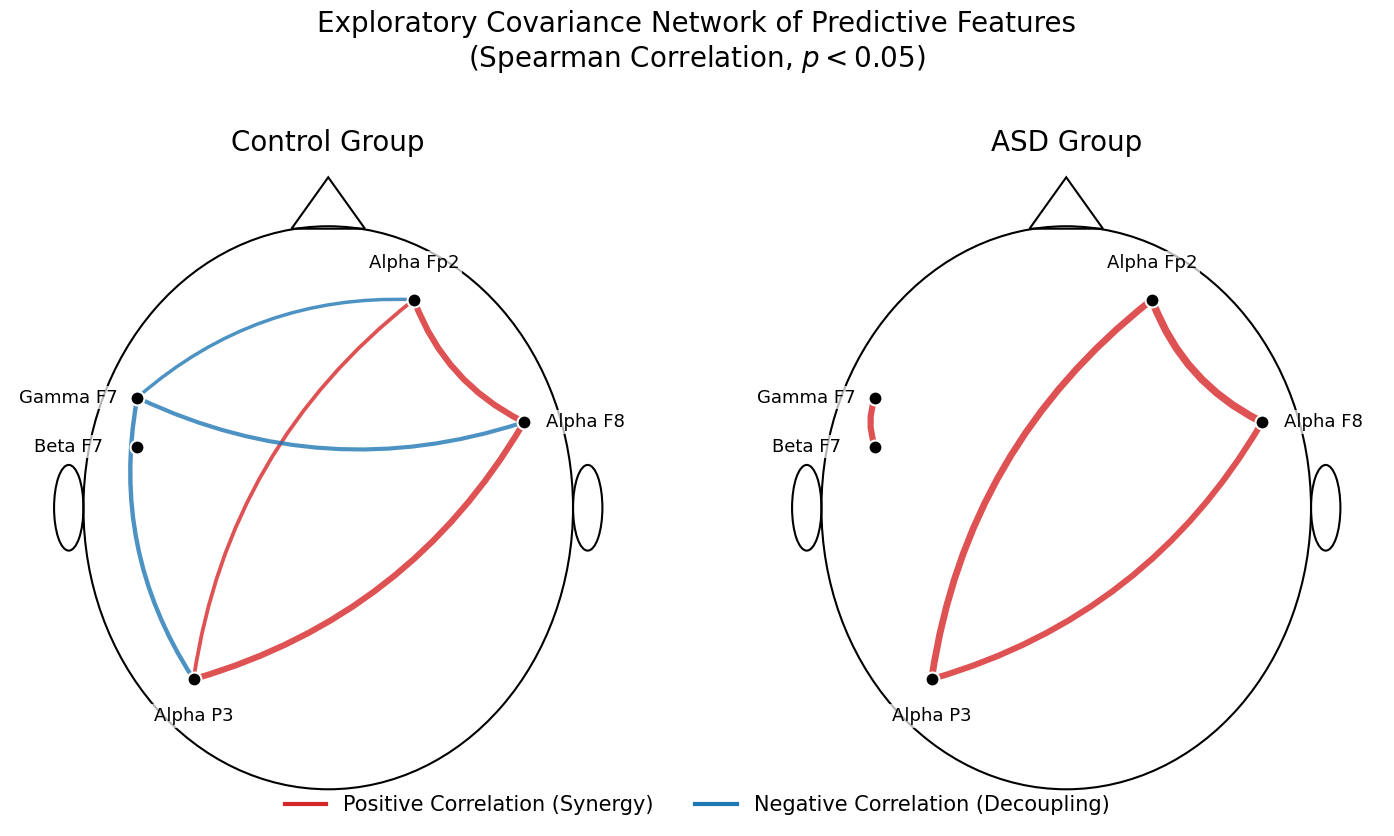

✅ Grafo Topológico Anatômico de Alto Padrão gerado com sucesso!


In [19]:
# 06. EXPLORAÇÃO SUPLEMENTAR (S2): TOPOLOGICAL CORRELATION NETWORK (ESTÉTICA REALISTA/MRI)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from matplotlib.patches import Ellipse, Polygon, FancyArrowPatch
from matplotlib.lines import Line2D
import os
import warnings

warnings.filterwarnings("ignore")

# 1. Configurações Visuais (Removido TODOS os negritos conforme solicitado)
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'font.weight': 'normal',
    'axes.titleweight': 'normal',
    'axes.labelweight': 'normal',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

# 2. Carregamento de Dados
caminho_csv = '../reports/tabela_features_eeg_completa.csv'
df = pd.read_csv(caminho_csv)

df_f = df[df['Condicao'] == 'Face Feliz'].copy()
df_f = df_f.groupby(['ID', 'Grupo']).mean(numeric_only=True).reset_index()

y = df_f['Grupo'].apply(lambda x: 1 if 'TEA' in x else 0).values
df_tea = df_f[y == 1]
df_ctrl = df_f[y == 0]

# 3. Coordenadas Anatômicas (Adaptadas para um crânio oval/realista)
features_ouro = ['AlphaRel_Fp2', 'GammaRel_F7', 'BetaRel_F7', 'AlphaRel_P3', 'AlphaRel_F8']
nomes_limpos = ['Alpha Fp2', 'Gamma F7', 'Beta F7', 'Alpha P3', 'Alpha F8']

# Coordenadas ajustadas para o eixo Y ligeiramente alongado
posicoes = {
    'Alpha Fp2': (0.35, 0.85),
    'Gamma F7': (-0.78, 0.45),
    'Beta F7': (-0.78, 0.25),
    'Alpha F8': (0.80, 0.35),
    'Alpha P3': (-0.55, -0.70)
}

# 4. Função de Desenho da Cabeça Realista
# # 4. Função de Desenho da Cabeça Realista
def desenhar_cabeca_realista(ax):
    ax.set_aspect('equal')
    
    # 4.1. Contorno Craniano
    cabeca = Ellipse((0, 0), width=2.0, height=2.3, color='black', fill=False, lw=1.5, zorder=2)
    ax.add_patch(cabeca)
    
    # 4.2. Inserção do Encéfalo Transparente
    caminho_cerebro = 'SEU_ARQUIVO_AQUI.png' # Coloque o caminho exato aqui
    
    if os.path.exists(caminho_cerebro):
        img_cerebro = plt.imread(caminho_cerebro)
        
        # --- CONTROLES MANUAIS PARA ENCAIXAR O SEU PNG ---
        # Aumente esses números se o cérebro estiver pequeno, diminua se vazar do crânio
        escala_x = 1.05  # Largura da imagem
        escala_y = 1.15  # Altura da imagem
        
        # Se o cérebro estiver muito para cima ou para baixo, mude esse valor (ex: -0.05 ou 0.05)
        deslocamento_y = 0.00 
        
        limite_esq = -escala_x
        limite_dir = escala_x
        limite_baixo = -escala_y + deslocamento_y
        limite_cima = escala_y + deslocamento_y
        
        # Plota a imagem perfeitamente transparente por baixo das linhas (zorder=0)
        ax.imshow(img_cerebro, extent=[limite_esq, limite_dir, limite_baixo, limite_cima], 
                  zorder=0, alpha=0.5)
    
    # 4.3. Nariz
    nariz = Polygon([(-0.15, 1.14), (0, 1.35), (0.15, 1.14)], color='black', fill=False, lw=1.5, zorder=2)
    ax.add_patch(nariz)
    
    # 4.4. Orelhas
    orelha_esq = Ellipse((-1.06, 0), width=0.12, height=0.35, angle=0, color='black', fill=False, lw=1.5, zorder=2)
    orelha_dir = Ellipse((1.06, 0), width=0.12, height=0.35, angle=0, color='black', fill=False, lw=1.5, zorder=2)
    ax.add_patch(orelha_esq)
    ax.add_patch(orelha_dir)
    
    # 4.5. Limpeza do eixo
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.4)
    ax.axis('off')
    
# 5. Motor de Correlação e Desenho da Rede com Linhas Curvas
def plotar_rede(df_grupo, titulo, ax):
    desenhar_cabeca_realista(ax)
    ax.set_title(titulo, pad=10, fontsize=20, fontweight='normal')
    
    dados = df_grupo[features_ouro].dropna()
    n_features = len(features_ouro)
    
    # Desenho das Arestas Curvas (Conexões)
    for i in range(n_features):
        for j in range(i + 1, n_features):
            feat1, feat2 = features_ouro[i], features_ouro[j]
            nome1, nome2 = nomes_limpos[i], nomes_limpos[j]
            
            r, p = spearmanr(dados[feat1], dados[feat2])
            
            if p < 0.05:
                x1, y1 = posicoes[nome1]
                x2, y2 = posicoes[nome2]
                
                espessura = abs(r) * 6
                # Vermelho e Azul puros (mantendo transparência para ver o cérebro no fundo)
                cor = '#D62728' if r > 0 else '#1F77B4'
                
                # O segredo das curvas orgânicas: FancyArrowPatch
                arco = FancyArrowPatch((x1, y1), (x2, y2),
                                       connectionstyle="arc3,rad=0.2", # Curvatura
                                       color=cor, lw=espessura, alpha=0.8, 
                                       zorder=2, arrowstyle="-") # Sem ponta de seta
                ax.add_patch(arco)

    # Desenho dos Nós (Eletrodos) e Textos
    for nome in nomes_limpos:
        x, y = posicoes[nome]
        
        # Ponto do eletrodo (Preto clássico com borda branca para destacar no fundo)
        ax.plot(x, y, marker='o', markersize=10, color='black', 
                markeredgecolor='white', markeredgewidth=1.5, zorder=3)
        
        # Textos com peso normal
        if 'F7' in nome:
            desloc_x, desloc_y = -0.28, 0 
        elif 'F8' in nome:
            desloc_x, desloc_y = 0.25, 0
        elif 'Fp2' in nome:
            desloc_x, desloc_y = 0, 0.15
        else:
            desloc_x, desloc_y = 0, -0.15
            
        ax.text(x + desloc_x, y + desloc_y, nome, ha='center', va='center', 
                fontsize=13, fontweight='normal', color='black', zorder=4,
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=2))

# 6. Construção da Figura
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
fig.suptitle('Exploratory Covariance Network of Predictive Features\n(Spearman Correlation, $p < 0.05$)', 
             fontsize=20, y=1.05, fontweight='normal')

plotar_rede(df_ctrl, 'Control Group', axes[0])
plotar_rede(df_tea, 'ASD Group', axes[1])

# Legenda Limpa
legend_elements = [
    Line2D([0], [0], color='#D62728', lw=3, label='Positive Correlation (Synergy)'),
    Line2D([0], [0], color='#1F77B4', lw=3, label='Negative Correlation (Decoupling)')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, 
           bbox_to_anchor=(0.5, 0.02), fontsize=15, frameon=False)

plt.tight_layout()

# 7. Salvamento e Exibição
os.makedirs('../reports/figures', exist_ok=True)
caminho_fig = '../reports/figures/figS2_topology_network_advanced.png'
plt.savefig(caminho_fig, dpi=300, bbox_inches='tight')
plt.show()

print("✅ Grafo Topológico Anatômico de Alto Padrão gerado com sucesso!")

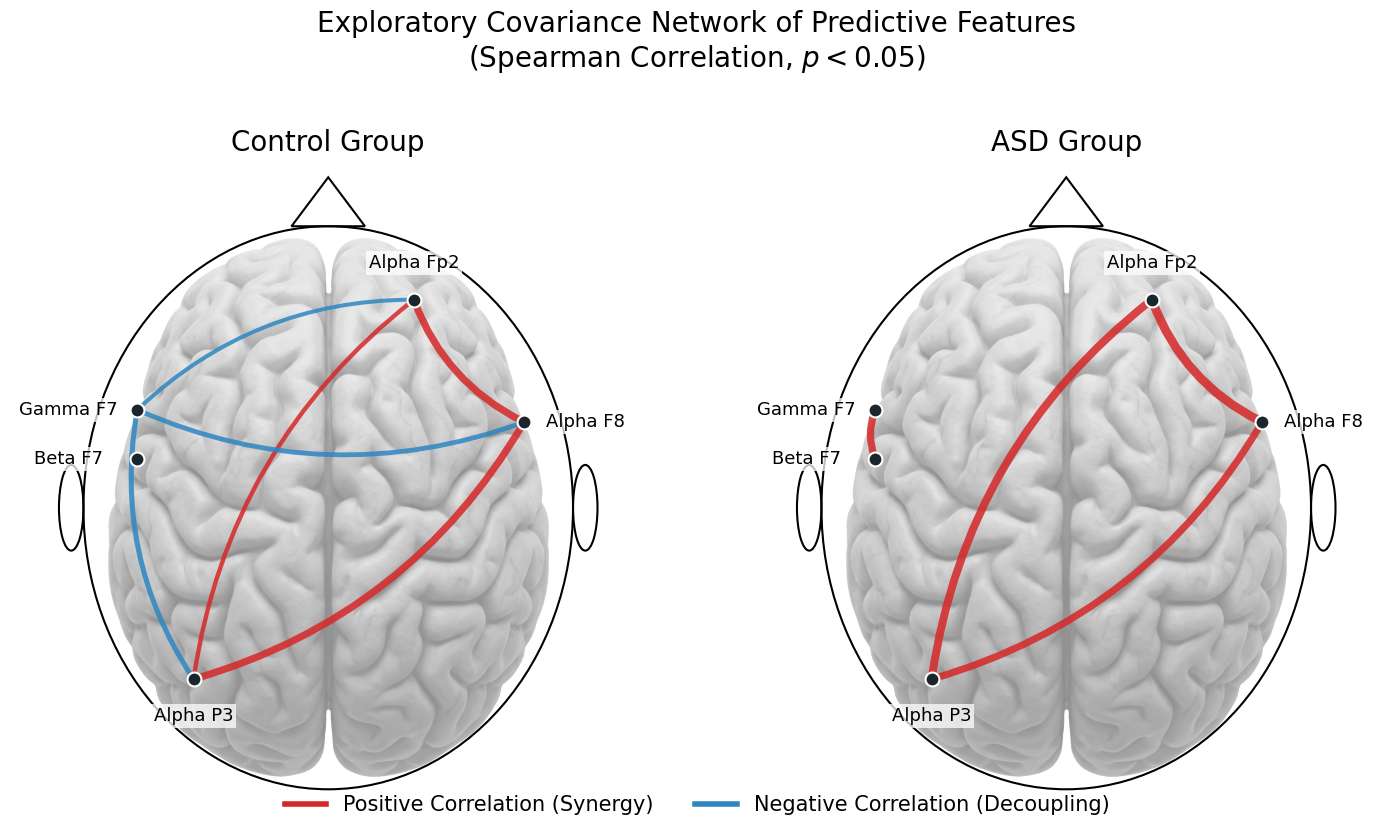

✅ Grafo Topológico Anatômico (com processamento de imagem) gerado!


In [21]:
# 06. EXPLORAÇÃO SUPLEMENTAR (S2): TOPOLOGICAL CORRELATION NETWORK (ESTÉTICA REALISTA/MRI)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from matplotlib.patches import Ellipse, Polygon, FancyArrowPatch
from matplotlib.lines import Line2D
import os
import warnings

warnings.filterwarnings("ignore")

# 1. Configurações Visuais (Sem negritos, estética limpa)
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'font.weight': 'normal',
    'axes.titleweight': 'normal',
    'axes.labelweight': 'normal',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

# 2. Carregamento de Dados
caminho_csv = '../reports/tabela_features_eeg_completa.csv'
df = pd.read_csv(caminho_csv)

df_f = df[df['Condicao'] == 'Face Feliz'].copy()
df_f = df_f.groupby(['ID', 'Grupo']).mean(numeric_only=True).reset_index()

y = df_f['Grupo'].apply(lambda x: 1 if 'TEA' in x else 0).values
df_tea = df_f[y == 1]
df_ctrl = df_f[y == 0]

# 3. Coordenadas Anatômicas (Adaptadas para um crânio oval/realista)
features_ouro = ['AlphaRel_Fp2', 'GammaRel_F7', 'BetaRel_F7', 'AlphaRel_P3', 'AlphaRel_F8']
nomes_limpos = ['Alpha Fp2', 'Gamma F7', 'Beta F7', 'Alpha P3', 'Alpha F8']

posicoes = {
    'Alpha Fp2': (0.35, 0.85),
    'Gamma F7': (-0.78, 0.40),
    'Beta F7': (-0.78, 0.20),
    'Alpha F8': (0.80, 0.35),
    'Alpha P3': (-0.55, -0.70)
}

# 4. Motor de Processamento de Imagem (Resolve o fundo branco e as margens do JPG)
def processar_imagem_cerebro(caminho):
    if not os.path.exists(caminho):
        return None
        
    img = plt.imread(caminho)
    if img.max() > 1.0:
        img = img / 255.0  # Normaliza para 0-1
        
    # Identifica o que é fundo branco (valores RGB próximos de 1.0)
    is_bg = (img[:,:,0] > 0.9) & (img[:,:,1] > 0.9) & (img[:,:,2] > 0.9)
    
    # Corta o excesso de margem branca (Bounding Box)
    rows = np.any(~is_bg, axis=1)
    cols = np.any(~is_bg, axis=0)
    if not np.any(rows) or not np.any(cols):
        return None # Imagem totalmente branca
        
    ymin, ymax = np.where(rows)[0][0], np.where(rows)[0][-1]
    xmin, xmax = np.where(cols)[0][0], np.where(cols)[0][-1]
    
    img_cropped = img[ymin:ymax, xmin:xmax]
    is_bg_cropped = is_bg[ymin:ymax, xmin:xmax]
    
    # Converte o cérebro colorido para Tons de Cinza Clínico (Estilo RM)
    gray = np.dot(img_cropped[..., :3], [0.2989, 0.5870, 0.1140])
    
    # Adiciona a transparência onde era o fundo branco original
    rgba = np.zeros((gray.shape[0], gray.shape[1], 4))
    for i in range(3):
        rgba[:,:,i] = gray
    rgba[:,:,3] = np.where(is_bg_cropped, 0.0, 0.45) # 0.45 é a opacidade ideal do cérebro
    
    return rgba

# 5. Função de Desenho da Cabeça Realista
def desenhar_cabeca_realista(ax):
    ax.set_aspect('equal')
    
    # 5.1. Inserção do Encéfalo Transparente Ajustado
    rgba_cerebro = processar_imagem_cerebro('brain_background.png')
    if rgba_cerebro is not None:
        # Extent ajustado para encaixar o cérebro perfeitamente no interior craniano
        ax.imshow(rgba_cerebro, extent=[-0.90, 0.90, -1.10, 1.10], zorder=0)
    
    # 5.2. Contorno Craniano (Elipse: largura 2.0, altura 2.3)
    cabeca = Ellipse((0, 0), width=2.0, height=2.3, color='black', fill=False, lw=1.5, zorder=1)
    ax.add_patch(cabeca)
    
    # 5.3. Nariz (Exatamente acima da linha craniana Y=1.15)
    nariz = Polygon([(-0.15, 1.15), (0, 1.35), (0.15, 1.15)], color='black', fill=False, lw=1.5, zorder=1)
    ax.add_patch(nariz)
    
    # 5.4. Orelhas (Exatamente ao lado da linha craniana X=-1.0 e X=1.0)
    orelha_esq = Ellipse((-1.05, 0), width=0.1, height=0.35, angle=0, color='black', fill=False, lw=1.5, zorder=1)
    orelha_dir = Ellipse((1.05, 0), width=0.1, height=0.35, angle=0, color='black', fill=False, lw=1.5, zorder=1)
    ax.add_patch(orelha_esq)
    ax.add_patch(orelha_dir)
    
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.4)
    ax.axis('off')

# 6. Motor de Correlação e Desenho da Rede (Linhas Curvas)
def plotar_rede(df_grupo, titulo, ax):
    desenhar_cabeca_realista(ax)
    ax.set_title(titulo, pad=10, fontsize=20, fontweight='normal')
    
    dados = df_grupo[features_ouro].dropna()
    n_features = len(features_ouro)
    
    # Arestas (Curvas de Sinergia e Trade-off)
    for i in range(n_features):
        for j in range(i + 1, n_features):
            feat1, feat2 = features_ouro[i], features_ouro[j]
            nome1, nome2 = nomes_limpos[i], nomes_limpos[j]
            
            r, p = spearmanr(dados[feat1], dados[feat2])
            
            if p < 0.05:
                x1, y1 = posicoes[nome1]
                x2, y2 = posicoes[nome2]
                
                espessura = abs(r) * 7  # Mais grosso para destacar no fundo cinza
                cor = '#D62728' if r > 0 else '#2E86C1' # Vermelho vs Azul Customizado
                
                # Curva elegante conectando as regiões
                arco = FancyArrowPatch((x1, y1), (x2, y2),
                                       connectionstyle="arc3,rad=0.2",
                                       color=cor, lw=espessura, alpha=0.85, 
                                       zorder=2, arrowstyle="-")
                ax.add_patch(arco)

    # Nós (Eletrodos) e Textos
    for nome in nomes_limpos:
        x, y = posicoes[nome]
        
        # Bolinhas escuras para contraste elegante
        ax.plot(x, y, marker='o', markersize=10, color='#1A252C', 
                markeredgecolor='white', markeredgewidth=1.5, zorder=3)
        
        # Ajuste espacial do texto
        if 'F7' in nome:
            desloc_x, desloc_y = -0.28, 0 
        elif 'F8' in nome:
            desloc_x, desloc_y = 0.25, 0
        elif 'Fp2' in nome:
            desloc_x, desloc_y = 0, 0.15
        else:
            desloc_x, desloc_y = 0, -0.15
            
        ax.text(x + desloc_x, y + desloc_y, nome, ha='center', va='center', 
                fontsize=13, fontweight='normal', color='black', zorder=4,
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=2))

# 7. Construção e Finalização da Figura
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
fig.suptitle('Exploratory Covariance Network of Predictive Features\n(Spearman Correlation, $p < 0.05$)', 
             fontsize=20, y=1.05, fontweight='normal')

plotar_rede(df_ctrl, 'Control Group', axes[0])
plotar_rede(df_tea, 'ASD Group', axes[1])

# Legenda Simples e Limpa
legend_elements = [
    Line2D([0], [0], color='#D62728', lw=4, label='Positive Correlation (Synergy)'),
    Line2D([0], [0], color='#2E86C1', lw=4, label='Negative Correlation (Decoupling)')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, 
           bbox_to_anchor=(0.5, 0.02), fontsize=15, frameon=False)

plt.tight_layout()

# 8. Salvamento
os.makedirs('../reports/figures', exist_ok=True)
caminho_fig = '../reports/figures/figS2_topology_network_advanced.png'
plt.savefig(caminho_fig, dpi=300, bbox_inches='tight')
plt.show()

print("✅ Grafo Topológico Anatômico (com processamento de imagem) gerado!")

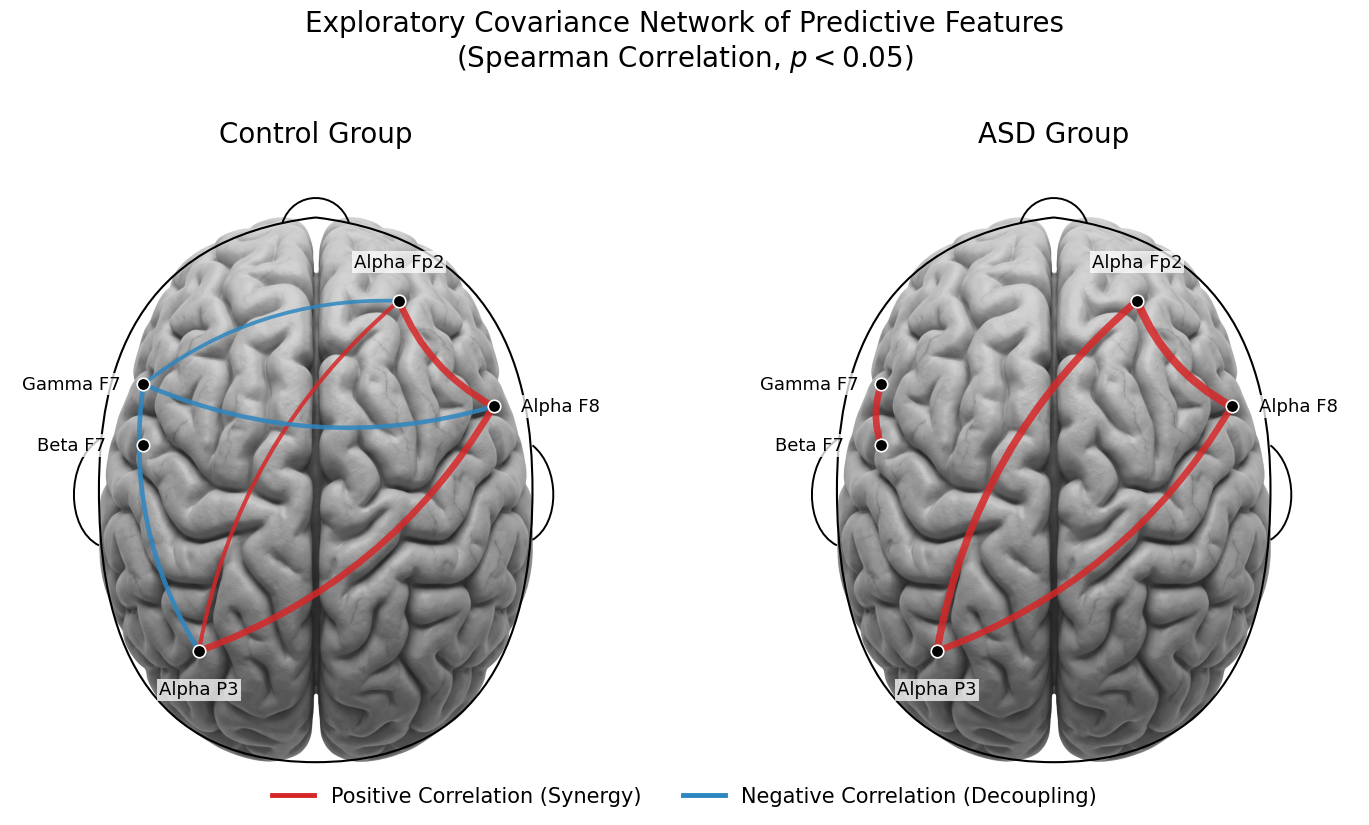

✅ Figura S2 ajustada com proporções anatômicas reais gerada com sucesso!


In [1]:
# 06. EXPLORAÇÃO SUPLEMENTAR (S2): TOPOLOGICAL CORRELATION NETWORK (ANATÔMICO REALISTA)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from matplotlib.patches import PathPatch, FancyArrowPatch
from matplotlib.path import Path
from matplotlib.lines import Line2D
import os
import warnings

warnings.filterwarnings("ignore")

# 1. Configurações Visuais (Tipografia limpa, sem negritos)
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'font.weight': 'normal',
    'axes.titleweight': 'normal',
    'axes.labelweight': 'normal',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

# 2. Carregamento e Preparação dos Dados
caminho_csv = '../reports/tabela_features_eeg_completa.csv'
df = pd.read_csv(caminho_csv)

df_f = df[df['Condicao'] == 'Face Feliz'].copy()
df_f = df_f.groupby(['ID', 'Grupo']).mean(numeric_only=True).reset_index()

y = df_f['Grupo'].apply(lambda x: 1 if 'TEA' in x else 0).values
df_tea = df_f[y == 1]
df_ctrl = df_f[y == 0]

# 3. Coordenadas dos Eletrodos Ajustadas ao Córtex (X, Y)
features_ouro = ['AlphaRel_Fp2', 'GammaRel_F7', 'BetaRel_F7', 'AlphaRel_P3', 'AlphaRel_F8']
nomes_limpos = ['Alpha Fp2', 'Gamma F7', 'Beta F7', 'Alpha P3', 'Alpha F8']

posicoes = {
    'Alpha Fp2': (0.30, 0.68),
    'Gamma F7': (-0.62, 0.38),
    'Beta F7': (-0.62, 0.16),
    'Alpha F8': (0.64, 0.30),
    'Alpha P3': (-0.42, -0.58)
}

# 4. Motor de Processamento de Imagem (Crop Justo e Conversão para Cinza Clínico)
def processar_imagem_cerebro(caminho):
    if not os.path.exists(caminho):
        return None
        
    img = plt.imread(caminho)
    if img.max() > 1.0:
        img = img / 255.0
        
    # Detecta fundo branco ou transparente
    if img.shape[2] == 4:
        is_bg = (img[:,:,3] < 0.1) | ((img[:,:,0] > 0.9) & (img[:,:,1] > 0.9) & (img[:,:,2] > 0.9))
    else:
        is_bg = (img[:,:,0] > 0.9) & (img[:,:,1] > 0.9) & (img[:,:,2] > 0.9)
        
    rows = np.any(~is_bg, axis=1)
    cols = np.any(~is_bg, axis=0)
    if not np.any(rows) or not np.any(cols):
        return img
        
    ymin, ymax = np.where(rows)[0][0], np.where(rows)[0][-1]
    xmin, xmax = np.where(cols)[0][0], np.where(cols)[0][-1]
    
    img_cropped = img[ymin:ymax, xmin:xmax]
    is_bg_cropped = is_bg[ymin:ymax, xmin:xmax]
    
    # Converte para tons de cinza clínico
    gray = np.dot(img_cropped[..., :3], [0.2989, 0.5870, 0.1140])
    
    rgba = np.zeros((gray.shape[0], gray.shape[1], 4))
    for i in range(3):
        rgba[:,:,i] = gray
    rgba[:,:,3] = np.where(is_bg_cropped, 0.0, 0.88) # Alta opacidade para preencher bem
    
    return rgba

# 5. Desenho Anatômico Orgânico (Crânio, Nariz '∩' e Orelhas em 'C')
def desenhar_cabeca_anatomica(ax):
    ax.set_aspect('equal')
    
    # 5.1. Inserção do Encéfalo Preenchendo todo o Cavidade Craniana
    rgba_cerebro = processar_imagem_cerebro('brain_background.png')
    if rgba_cerebro is not None:
        ax.imshow(rgba_cerebro, extent=[-0.78, 0.78, -0.98, 0.98], zorder=0)
    
    # 5.2. Contorno Craniano Anatômico (Levemente ovalado, estreito na frente)
    head_verts = [
        (0.0, 0.98),                                 # Topo Frontal
        (0.66, 0.90), (0.78, 0.42), (0.78, 0.0),      # Lado Direito
        (0.78, -0.42), (0.68, -0.98), (0.0, -0.98),  # Base Occipital
        (-0.68, -0.98), (-0.78, -0.42), (-0.78, 0.0), # Lado Esquerdo
        (-0.78, 0.42), (-0.66, 0.90), (0.0, 0.98)    # Fechamento Frontal
    ]
    head_codes = [
        Path.MOVETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.CURVE4, Path.CURVE4, Path.CURVE4
    ]
    ax.add_patch(PathPatch(Path(head_verts, head_codes), facecolor='none', edgecolor='black', lw=1.5, zorder=2))
    
    # 5.3. Nariz Orgânico em formato de '∩' (Projeção superior, baixo e arredondado)
    nose_verts = [
        (-0.12, 0.96),
        (-0.08, 1.08), (0.08, 1.08), (0.12, 0.96)
    ]
    nose_codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
    ax.add_patch(PathPatch(Path(nose_verts, nose_codes), facecolor='none', edgecolor='black', lw=1.4, zorder=2))
    
    # 5.4. Orelha Esquerda Orgânica (Formato de vírgula/C levemente mais aberta)
    ear_l_verts = [
        (-0.78, 0.18),
        (-0.90, 0.10), (-0.90, -0.14), (-0.78, -0.20)
    ]
    ear_codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
    ax.add_patch(PathPatch(Path(ear_l_verts, ear_codes), facecolor='none', edgecolor='black', lw=1.4, zorder=2))
    
    # 5.5. Orelha Direita Orgânica (Formato de vírgula/C ligeiramente mais discreta)
    ear_r_verts = [
        (0.78, 0.16),
        (0.88, 0.08), (0.88, -0.12), (0.78, -0.18)
    ]
    ax.add_patch(PathPatch(Path(ear_r_verts, ear_codes), facecolor='none', edgecolor='black', lw=1.4, zorder=2))
    
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.15, 1.20)
    ax.axis('off')

# 6. Motor de Plotagem das Redes de Covariância
def plotar_rede(df_grupo, titulo, ax):
    desenhar_cabeca_anatomica(ax)
    ax.set_title(titulo, pad=10, fontsize=20, fontweight='normal')
    
    dados = df_grupo[features_ouro].dropna()
    n_features = len(features_ouro)
    
    # Arestas Curvas
    for i in range(n_features):
        for j in range(i + 1, n_features):
            feat1, feat2 = features_ouro[i], features_ouro[j]
            nome1, nome2 = nomes_limpos[i], nomes_limpos[j]
            
            r, p = spearmanr(dados[feat1], dados[feat2])
            
            if p < 0.05:
                x1, y1 = posicoes[nome1]
                x2, y2 = posicoes[nome2]
                
                espessura = abs(r) * 6.5
                cor = '#D62728' if r > 0 else '#2E86C1'
                
                arco = FancyArrowPatch((x1, y1), (x2, y2),
                                       connectionstyle="arc3,rad=0.18",
                                       color=cor, lw=espessura, alpha=0.85, 
                                       zorder=3, arrowstyle="-")
                ax.add_patch(arco)

    # Nós e Rótulos
    for nome in nomes_limpos:
        x, y = posicoes[nome]
        
        ax.plot(x, y, marker='o', markersize=9, color='black', 
                markeredgecolor='white', markeredgewidth=1.2, zorder=4)
        
        if 'F7' in nome:
            desloc_x, desloc_y = -0.26, 0 
        elif 'F8' in nome:
            desloc_x, desloc_y = 0.24, 0
        elif 'Fp2' in nome:
            desloc_x, desloc_y = 0, 0.14
        else:
            desloc_x, desloc_y = 0, -0.14
            
        ax.text(x + desloc_x, y + desloc_y, nome, ha='center', va='center', 
                fontsize=13, fontweight='normal', color='black', zorder=5,
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=1.5))

# 7. Geração da Figura Final
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
fig.suptitle('Exploratory Covariance Network of Predictive Features\n(Spearman Correlation, $p < 0.05$)', 
             fontsize=20, y=1.03, fontweight='normal')

plotar_rede(df_ctrl, 'Control Group', axes[0])
plotar_rede(df_tea, 'ASD Group', axes[1])

# Legenda Sem Moldura
legend_elements = [
    Line2D([0], [0], color='#D62728', lw=3.5, label='Positive Correlation (Synergy)'),
    Line2D([0], [0], color='#2E86C1', lw=3.5, label='Negative Correlation (Decoupling)')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, 
           bbox_to_anchor=(0.5, 0.01), fontsize=15, frameon=False)

plt.tight_layout()

# 8. Salvamento
os.makedirs('../reports/figures', exist_ok=True)
caminho_fig = '../reports/figures/figS2_topology_network_anatomical.png'
plt.savefig(caminho_fig, dpi=300, bbox_inches='tight')
plt.show()

print("✅ Figura S2 ajustada com proporções anatômicas reais gerada com sucesso!")

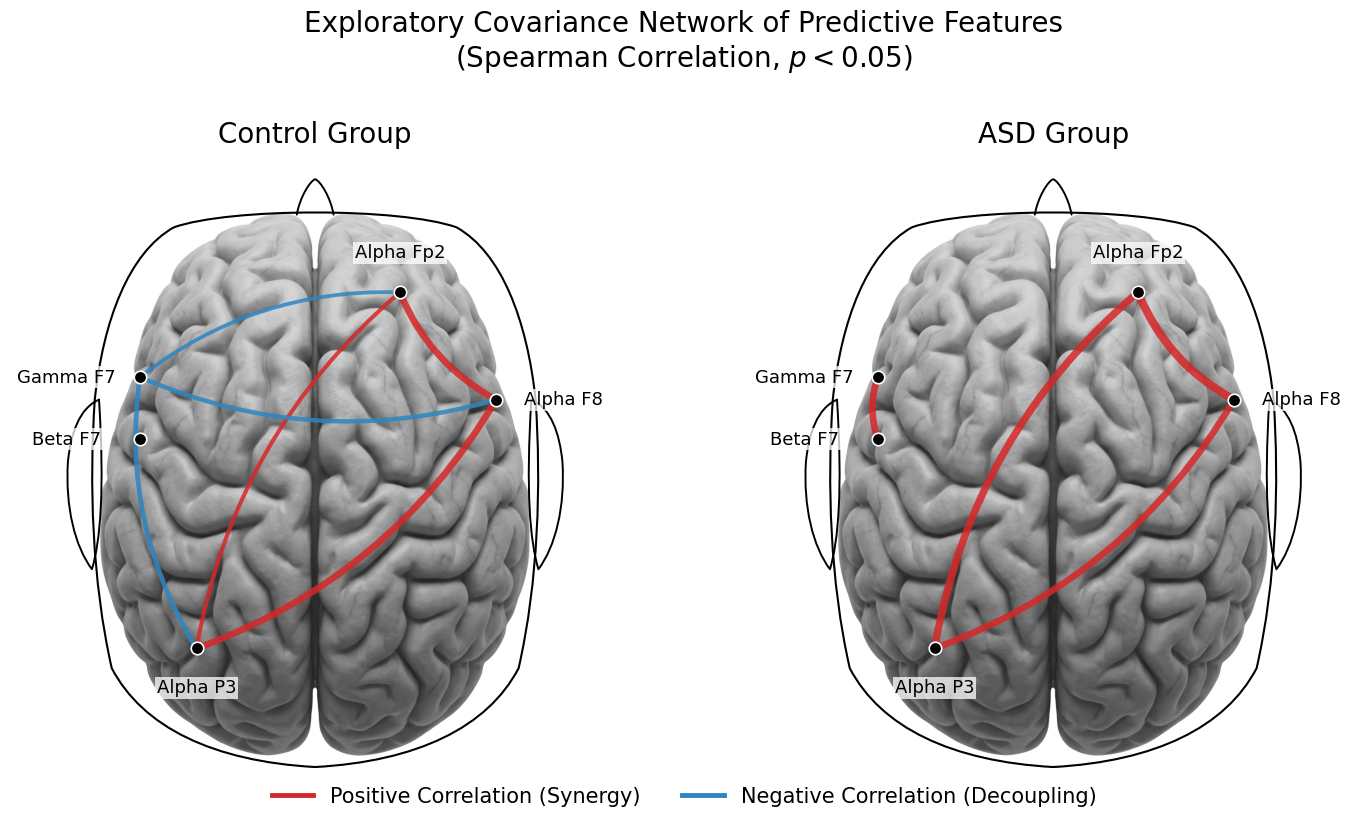

✅ Figura S2 anatômica ajustada gerada com sucesso!


In [3]:
# 06. EXPLORAÇÃO SUPLEMENTAR (S2): TOPOLOGICAL CORRELATION NETWORK
# ANATOMIA CEREBRAL REALISTA — VERSÃO AJUSTADA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from matplotlib.patches import PathPatch, FancyArrowPatch
from matplotlib.path import Path
from matplotlib.lines import Line2D
import os
import warnings

warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIGURAÇÕES VISUAIS
# ============================================================

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'font.weight': 'normal',
    'axes.titleweight': 'normal',
    'axes.labelweight': 'normal',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})


# ============================================================
# 2. CARREGAMENTO E PREPARAÇÃO DOS DADOS
# ============================================================

caminho_csv = '../reports/tabela_features_eeg_completa.csv'

df = pd.read_csv(caminho_csv)

df_f = df[df['Condicao'] == 'Face Feliz'].copy()

df_f = (
    df_f
    .groupby(['ID', 'Grupo'])
    .mean(numeric_only=True)
    .reset_index()
)

y = df_f['Grupo'].apply(
    lambda x: 1 if 'TEA' in x else 0
).values

df_tea = df_f[y == 1]
df_ctrl = df_f[y == 0]


# ============================================================
# 3. FEATURES E POSIÇÕES DOS ELETRODOS
# ============================================================

features_ouro = [
    'AlphaRel_Fp2',
    'GammaRel_F7',
    'BetaRel_F7',
    'AlphaRel_P3',
    'AlphaRel_F8'
]

nomes_limpos = [
    'Alpha Fp2',
    'Gamma F7',
    'Beta F7',
    'Alpha P3',
    'Alpha F8'
]

posicoes = {
    'Alpha Fp2': (0.30, 0.68),
    'Gamma F7': (-0.62, 0.38),
    'Beta F7': (-0.62, 0.16),
    'Alpha F8': (0.64, 0.30),
    'Alpha P3': (-0.42, -0.58)
}


# ============================================================
# 4. PROCESSAMENTO DA IMAGEM CEREBRAL
# ============================================================

def processar_imagem_cerebro(caminho):

    if not os.path.exists(caminho):
        return None

    img = plt.imread(caminho)

    if img.max() > 1.0:
        img = img / 255.0

    # --------------------------------------------------------
    # Detecta fundo branco/transparente
    # --------------------------------------------------------

    if img.shape[2] == 4:

        is_bg = (
            (img[:, :, 3] < 0.1) |
            (
                (img[:, :, 0] > 0.9) &
                (img[:, :, 1] > 0.9) &
                (img[:, :, 2] > 0.9)
            )
        )

    else:

        is_bg = (
            (img[:, :, 0] > 0.9) &
            (img[:, :, 1] > 0.9) &
            (img[:, :, 2] > 0.9)
        )

    rows = np.any(~is_bg, axis=1)
    cols = np.any(~is_bg, axis=0)

    if not np.any(rows) or not np.any(cols):
        return img

    ymin, ymax = np.where(rows)[0][0], np.where(rows)[0][-1]
    xmin, xmax = np.where(cols)[0][0], np.where(cols)[0][-1]

    # +1 para não cortar a última linha/coluna
    img_cropped = img[ymin:ymax + 1, xmin:xmax + 1]
    is_bg_cropped = is_bg[ymin:ymax + 1, xmin:xmax + 1]

    # --------------------------------------------------------
    # Conversão para escala de cinza
    # --------------------------------------------------------

    gray = np.dot(
        img_cropped[..., :3],
        [0.2989, 0.5870, 0.1140]
    )

    rgba = np.zeros(
        (gray.shape[0], gray.shape[1], 4)
    )

    rgba[:, :, 0] = gray
    rgba[:, :, 1] = gray
    rgba[:, :, 2] = gray

    rgba[:, :, 3] = np.where(
        is_bg_cropped,
        0.0,
        0.88
    )

    return rgba


# ============================================================
# 5. GEOMETRIA ANATÔMICA DA CABEÇA
# ============================================================

def criar_path_cabeca():

    # --------------------------------------------------------
    # Vista superior:
    # topo = região frontal
    # baixo = região posterior/occipital
    #
    # A região frontal foi propositalmente achatada,
    # evitando o formato excessivamente pontudo/oval.
    # --------------------------------------------------------

    head_verts = [

        # FRONTAL SUPERIOR
        (-0.50, 0.91),
        (-0.30, 0.98),
        ( 0.30, 0.98),
        ( 0.50, 0.91),

        # FRONTAL-LATERAL DIREITA
        ( 0.66, 0.82),
        ( 0.75, 0.58),
        ( 0.78, 0.30),

        # LATERAL DIREITA
        ( 0.80, 0.00),
        ( 0.79,-0.34),
        ( 0.72,-0.65),

        # POSTERIOR
        ( 0.61,-0.86),
        ( 0.36,-0.98),
        ( 0.00,-1.00),

        (-0.36,-0.98),
        (-0.61,-0.86),

        # LATERAL ESQUERDA
        (-0.72,-0.65),
        (-0.79,-0.34),
        (-0.80, 0.00),

        (-0.78, 0.30),
        (-0.75, 0.58),
        (-0.66, 0.82),

        # FECHAMENTO FRONTAL
        (-0.50, 0.91)
    ]

    head_codes = [
        Path.MOVETO,

        # frontal
        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        # direita
        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        # posterior
        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        Path.CURVE4,
        Path.CURVE4,

        # esquerda
        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        # fechamento
        Path.CURVE4
    ]

    return Path(head_verts, head_codes)


# ============================================================
# 6. DESENHO ANATÔMICO
# ============================================================

def desenhar_cabeca_anatomica(ax):

    ax.set_aspect('equal')

    # --------------------------------------------------------
    # PATH DA CABEÇA
    # --------------------------------------------------------

    head_path = criar_path_cabeca()

    # --------------------------------------------------------
    # CÉREBRO
    #
    # O ponto principal desta versão:
    # a imagem cerebral é RECORTADA pelo interior do crânio.
    #
    # Isso impede que o cérebro ultrapasse o contorno externo.
    # --------------------------------------------------------

    rgba_cerebro = processar_imagem_cerebro(
        'brain_background.png'
    )

    if rgba_cerebro is not None:

        imagem = ax.imshow(
            rgba_cerebro,
            extent=[
                -0.76, 0.76,
                -0.96, 0.96
            ],
            zorder=0,
            interpolation='bilinear'
        )

        # Recorte anatômico rigoroso
        clip_patch = PathPatch(
            head_path,
            transform=ax.transData,
            facecolor='none',
            edgecolor='none'
        )

        ax.add_patch(clip_patch)

        imagem.set_clip_path(clip_patch)

    # --------------------------------------------------------
    # CONTORNO DO CRÂNIO
    # --------------------------------------------------------

    ax.add_patch(
        PathPatch(
            head_path,
            facecolor='none',
            edgecolor='black',
            lw=1.5,
            zorder=2
        )
    )

    # ========================================================
    # NARIZ
    # ========================================================
    #
    # Formato curto e triangular.
    # Não é um "∩".
    # Possui uma pequena ponta arredondada.
    #
    # O nariz fica discretamente projetado para cima,
    # sem criar uma estrutura exagerada.
    # ========================================================

    nose_verts = [
        (-0.065, 0.955),

        (-0.055, 1.015),
        (-0.018, 1.075),
        ( 0.000, 1.080),

        ( 0.018, 1.075),
        ( 0.055, 1.015),
        ( 0.065, 0.955)
    ]

    nose_codes = [
        Path.MOVETO,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4
    ]

    ax.add_patch(
        PathPatch(
            Path(nose_verts, nose_codes),
            facecolor='none',
            edgecolor='black',
            lw=1.4,
            capstyle='round',
            joinstyle='round',
            zorder=3
        )
    )

    # ========================================================
    # ORELHA ESQUERDA
    # ========================================================
    #
    # Forma orgânica, assimétrica e semelhante a uma gota
    # irregular, mas NÃO geométrica.
    #
    # A porção posterior (inferior) é mais volumosa.
    # A porção anterior (superior) é mais curta e estreita.
    #
    # Inclinação aproximada de 20 graus para trás.
    # ========================================================

    ear_left_verts = [

        # ponto anterior superior
        (-0.765, 0.30),

        # curva anterior curta
        (-0.835, 0.27),
        (-0.865, 0.18),
        (-0.875, 0.08),

        # região posterior mais ampla
        (-0.885, -0.08),
        (-0.850, -0.22),
        (-0.790, -0.30),

        # fechamento suave junto ao crânio
        (-0.760, -0.20),
        (-0.745, -0.02),
        (-0.765, 0.30)
    ]

    ear_codes = [
        Path.MOVETO,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4
    ]

    ax.add_patch(
        PathPatch(
            Path(ear_left_verts, ear_codes),
            facecolor='none',
            edgecolor='black',
            lw=1.4,
            capstyle='round',
            joinstyle='round',
            zorder=2
        )
    )

    # ========================================================
    # ORELHA DIREITA
    # ========================================================
    #
    # Espelhada, porém levemente assimétrica para evitar
    # aparência excessivamente artificial/geometrizada.
    # ========================================================

    ear_right_verts = [

        # ponto anterior superior
        (0.765, 0.30),

        # curva anterior curta
        (0.835, 0.27),
        (0.865, 0.18),
        (0.875, 0.08),

        # região posterior mais ampla
        (0.885, -0.08),
        (0.850, -0.22),
        (0.790, -0.30),

        # fechamento junto ao crânio
        (0.760, -0.20),
        (0.745, -0.02),
        (0.765, 0.30)
    ]

    ax.add_patch(
        PathPatch(
            Path(ear_right_verts, ear_codes),
            facecolor='none',
            edgecolor='black',
            lw=1.4,
            capstyle='round',
            joinstyle='round',
            zorder=2
        )
    )

    # --------------------------------------------------------
    # LIMITES DA FIGURA
    # --------------------------------------------------------

    ax.set_xlim(-1.08, 1.08)
    ax.set_ylim(-1.15, 1.16)

    ax.axis('off')


# ============================================================
# 7. MOTOR DE PLOTAGEM DAS REDES
# ============================================================

def plotar_rede(df_grupo, titulo, ax):

    desenhar_cabeca_anatomica(ax)

    ax.set_title(
        titulo,
        pad=10,
        fontsize=20,
        fontweight='normal'
    )

    dados = df_grupo[features_ouro].dropna()

    n_features = len(features_ouro)

    # --------------------------------------------------------
    # ARESTAS DE CORRELAÇÃO
    # --------------------------------------------------------

    for i in range(n_features):

        for j in range(i + 1, n_features):

            feat1 = features_ouro[i]
            feat2 = features_ouro[j]

            nome1 = nomes_limpos[i]
            nome2 = nomes_limpos[j]

            r, p = spearmanr(
                dados[feat1],
                dados[feat2]
            )

            if p < 0.05:

                x1, y1 = posicoes[nome1]
                x2, y2 = posicoes[nome2]

                espessura = abs(r) * 6.5

                cor = (
                    '#D62728'
                    if r > 0
                    else '#2E86C1'
                )

                arco = FancyArrowPatch(
                    (x1, y1),
                    (x2, y2),
                    connectionstyle="arc3,rad=0.18",
                    color=cor,
                    lw=espessura,
                    alpha=0.85,
                    zorder=3,
                    arrowstyle="-"
                )

                ax.add_patch(arco)

    # --------------------------------------------------------
    # NÓS E RÓTULOS
    # --------------------------------------------------------

    for nome in nomes_limpos:

        x, y = posicoes[nome]

        ax.plot(
            x,
            y,
            marker='o',
            markersize=9,
            color='black',
            markeredgecolor='white',
            markeredgewidth=1.2,
            zorder=4
        )

        # Posicionamento dos rótulos
        if 'F7' in nome:

            desloc_x = -0.26
            desloc_y = 0

        elif 'F8' in nome:

            desloc_x = 0.24
            desloc_y = 0

        elif 'Fp2' in nome:

            desloc_x = 0
            desloc_y = 0.14

        else:

            desloc_x = 0
            desloc_y = -0.14

        ax.text(
            x + desloc_x,
            y + desloc_y,
            nome,
            ha='center',
            va='center',
            fontsize=13,
            fontweight='normal',
            color='black',
            zorder=5,
            bbox=dict(
                facecolor='white',
                edgecolor='none',
                alpha=0.75,
                pad=1.5
            )
        )


# ============================================================
# 8. GERAÇÃO DA FIGURA FINAL
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 8)
)

fig.suptitle(
    'Exploratory Covariance Network of Predictive Features\n'
    '(Spearman Correlation, $p < 0.05$)',
    fontsize=20,
    y=1.03,
    fontweight='normal'
)

plotar_rede(
    df_ctrl,
    'Control Group',
    axes[0]
)

plotar_rede(
    df_tea,
    'ASD Group',
    axes[1]
)


# ============================================================
# 9. LEGENDA
# ============================================================

legend_elements = [

    Line2D(
        [0],
        [0],
        color='#D62728',
        lw=3.5,
        label='Positive Correlation (Synergy)'
    ),

    Line2D(
        [0],
        [0],
        color='#2E86C1',
        lw=3.5,
        label='Negative Correlation (Decoupling)'
    )
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.5, 0.01),
    fontsize=15,
    frameon=False
)

plt.tight_layout()


# ============================================================
# 10. SALVAMENTO
# ============================================================

os.makedirs(
    '../reports/figures',
    exist_ok=True
)

caminho_fig = (
    '../reports/figures/'
    'figS2_topology_network_anatomical.png'
)

plt.savefig(
    caminho_fig,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print(
    "✅ Figura S2 anatômica ajustada gerada com sucesso!"
)

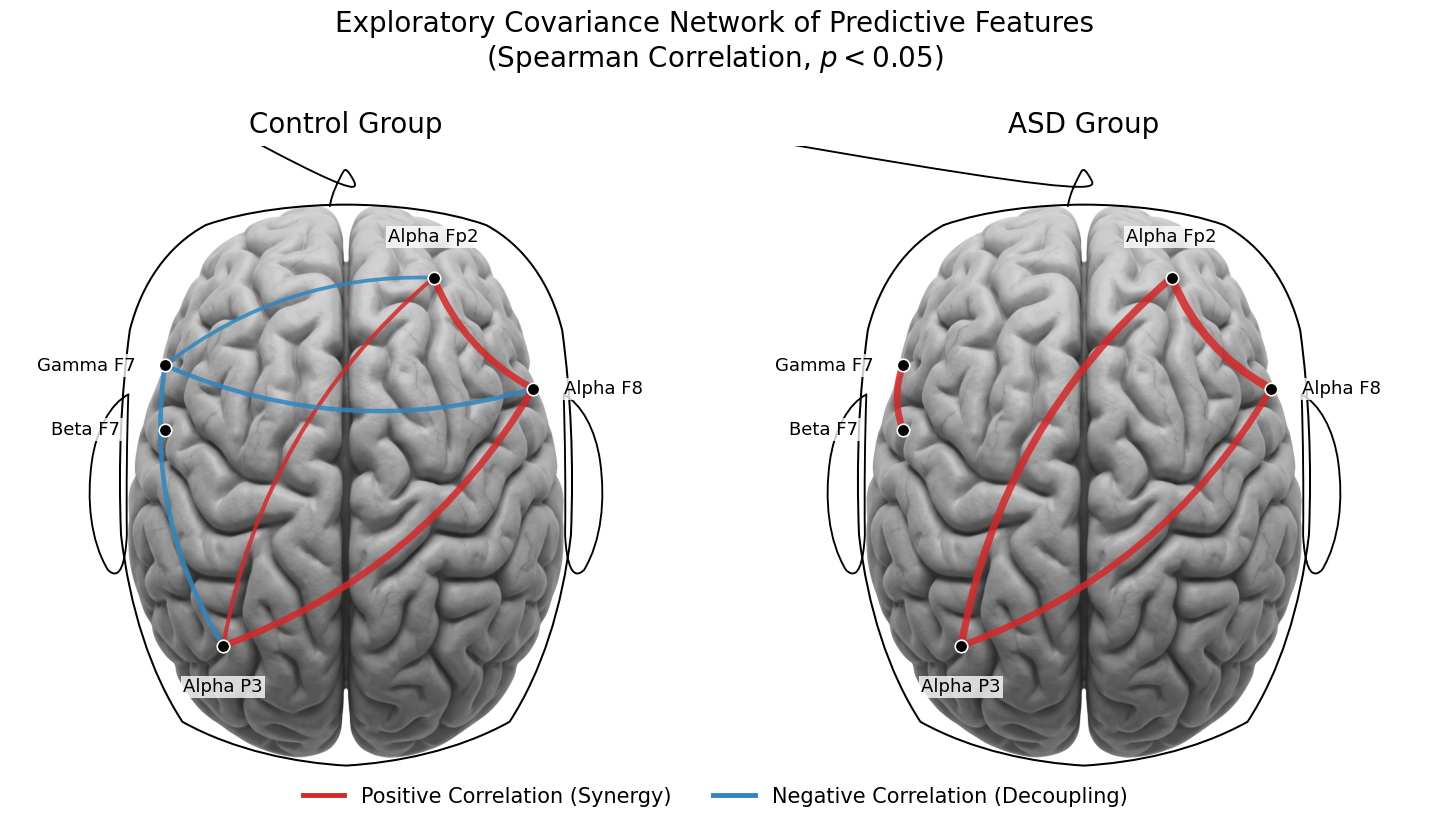

✅ Figura S2 gerada com contorno craniano, orelhas e nariz anatomicamente ajustados.


In [4]:
# ============================================================
# 06. EXPLORAÇÃO SUPLEMENTAR (S2)
# TOPOLOGICAL CORRELATION NETWORK — ANATOMIA AJUSTADA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from matplotlib.patches import PathPatch, FancyArrowPatch
from matplotlib.path import Path
from matplotlib.lines import Line2D
import os
import warnings

warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIGURAÇÕES VISUAIS
# ============================================================

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'font.weight': 'normal',
    'axes.titleweight': 'normal',
    'axes.labelweight': 'normal',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})


# ============================================================
# 2. CARREGAMENTO E PREPARAÇÃO DOS DADOS
# ============================================================

caminho_csv = '../reports/tabela_features_eeg_completa.csv'

df = pd.read_csv(caminho_csv)

df_f = df[df['Condicao'] == 'Face Feliz'].copy()

df_f = (
    df_f
    .groupby(['ID', 'Grupo'])
    .mean(numeric_only=True)
    .reset_index()
)

y = df_f['Grupo'].apply(
    lambda x: 1 if 'TEA' in x else 0
).values

df_tea = df_f[y == 1]
df_ctrl = df_f[y == 0]


# ============================================================
# 3. FEATURES E POSIÇÕES
# ============================================================

features_ouro = [
    'AlphaRel_Fp2',
    'GammaRel_F7',
    'BetaRel_F7',
    'AlphaRel_P3',
    'AlphaRel_F8'
]

nomes_limpos = [
    'Alpha Fp2',
    'Gamma F7',
    'Beta F7',
    'Alpha P3',
    'Alpha F8'
]

posicoes = {
    'Alpha Fp2': (0.30, 0.68),
    'Gamma F7': (-0.62, 0.38),
    'Beta F7': (-0.62, 0.16),
    'Alpha F8': (0.64, 0.30),
    'Alpha P3': (-0.42, -0.58)
}


# ============================================================
# 4. PROCESSAMENTO DA IMAGEM DO CÉREBRO
# ============================================================

def processar_imagem_cerebro(caminho):

    if not os.path.exists(caminho):
        return None

    img = plt.imread(caminho)

    if img.max() > 1.0:
        img = img / 255.0

    # --------------------------------------------------------
    # Identificação do fundo
    # --------------------------------------------------------

    if img.shape[2] == 4:

        is_bg = (
            (img[:, :, 3] < 0.1) |
            (
                (img[:, :, 0] > 0.94) &
                (img[:, :, 1] > 0.94) &
                (img[:, :, 2] > 0.94)
            )
        )

    else:

        is_bg = (
            (img[:, :, 0] > 0.94) &
            (img[:, :, 1] > 0.94) &
            (img[:, :, 2] > 0.94)
        )

    rows = np.any(~is_bg, axis=1)
    cols = np.any(~is_bg, axis=0)

    if not np.any(rows) or not np.any(cols):
        return img

    ymin, ymax = np.where(rows)[0][0], np.where(rows)[0][-1]
    xmin, xmax = np.where(cols)[0][0], np.where(cols)[0][-1]

    img_cropped = img[ymin:ymax + 1, xmin:xmax + 1]
    is_bg_cropped = is_bg[ymin:ymax + 1, xmin:xmax + 1]

    # --------------------------------------------------------
    # Escala de cinza
    # --------------------------------------------------------

    gray = np.dot(
        img_cropped[..., :3],
        [0.2989, 0.5870, 0.1140]
    )

    rgba = np.zeros(
        (gray.shape[0], gray.shape[1], 4)
    )

    rgba[:, :, 0] = gray
    rgba[:, :, 1] = gray
    rgba[:, :, 2] = gray

    rgba[:, :, 3] = np.where(
        is_bg_cropped,
        0.0,
        0.88
    )

    return rgba


# ============================================================
# 5. CONTORNO CRANIANO
#
# IMPORTANTE:
# O erro da versão anterior estava principalmente aqui.
#
# O contorno estava:
# - largo demais nas laterais;
# - excessivamente quadrado;
# - muito afastado do cérebro;
# - criando a impressão de uma "caixa" ao redor do cérebro.
#
# Agora o contorno acompanha melhor a morfologia do encéfalo:
# - frontal relativamente achatado;
# - laterais suavemente convexas;
# - região posterior mais arredondada;
# - sem ângulos artificiais.
# ============================================================

def criar_contorno_craniano():

    vertices = [

        # ----------------------------------------------------
        # FRONTAL
        # ----------------------------------------------------

        (-0.48, 0.86),

        (-0.34, 0.91),
        (-0.15, 0.93),
        ( 0.00, 0.93),

        ( 0.15, 0.93),
        ( 0.34, 0.91),
        ( 0.48, 0.86),

        # ----------------------------------------------------
        # FRONTAL-LATERAL DIREITA
        # ----------------------------------------------------

        (0.61, 0.79),
        (0.70, 0.66),
        (0.74, 0.50),

        # ----------------------------------------------------
        # LATERAL DIREITA
        # ----------------------------------------------------

        (0.77, 0.28),
        (0.78, 0.05),
        (0.77, -0.20),

        (0.74, -0.45),
        (0.67, -0.67),

        # ----------------------------------------------------
        # OCCIPITAL
        # ----------------------------------------------------

        (0.56, -0.84),
        (0.38, -0.94),
        (0.17, -0.98),

        (0.00, -0.99),

        (-0.17, -0.98),
        (-0.38, -0.94),
        (-0.56, -0.84),

        # ----------------------------------------------------
        # LATERAL ESQUERDA
        # ----------------------------------------------------

        (-0.67, -0.67),
        (-0.74, -0.45),
        (-0.77, -0.20),

        (-0.78, 0.05),
        (-0.77, 0.28),
        (-0.74, 0.50),

        # ----------------------------------------------------
        # FRONTAL-LATERAL ESQUERDA
        # ----------------------------------------------------

        (-0.70, 0.66),
        (-0.61, 0.79),
        (-0.48, 0.86)
    ]

    codes = [Path.MOVETO] + [Path.CURVE4] * (
        len(vertices) - 1
    )

    return Path(vertices, codes)


# ============================================================
# 6. NARIZ — TRIANGULAR, CURTO E ARREDONDADO
#
# O nariz NÃO será mais um arco em "∩".
#
# Forma:
# - base muito estreita;
# - projeção curta;
# - formato triangular;
# - ponta arredondada;
# - integrado ao contorno frontal.
# ============================================================

def criar_nariz():

    vertices = [

        # início esquerdo da base
        (-0.055, 0.925),

        # pequena expansão
        (-0.050, 0.965),
        (-0.025, 1.015),
        (-0.008, 1.045),

        # ponta arredondada
        (0.000, 1.055),
        (0.008, 1.045),
        (0.025, 1.015),

        # retorno
        (0.050, 0.965),
        (0.055, 0.925)
    ]

    codes = [
        Path.MOVETO,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        Path.CURVE4,
        Path.CURVE4
    ]

    return Path(vertices, codes)


# ============================================================
# 7. ORELHAS
#
# NOVA ABORDAGEM:
#
# Não usar "C", círculo ou oval.
#
# Cada orelha tem formato orgânico semelhante a uma gota
# irregular inclinada:
#
# - parte anterior = curta e estreita;
# - parte posterior = maior e mais volumosa;
# - extremidades arredondadas;
# - inclinação aproximada de 20°;
# - sem aparência geométrica.
#
# As orelhas ficam ATRÁS do contorno craniano.
# ============================================================

def criar_orelha_esquerda():

    vertices = [

        # ponto superior/anterior
        (-0.745, 0.28),

        # frente curta
        (-0.805, 0.25),
        (-0.855, 0.16),
        (-0.870, 0.05),

        # maior volume posterior
        (-0.888, -0.08),
        (-0.875, -0.22),
        (-0.815, -0.32),

        # extremidade inferior arredondada
        (-0.775, -0.36),
        (-0.755, -0.30),
        (-0.750, -0.20),

        # retorno ao crânio
        (-0.752, -0.05),
        (-0.750, 0.13),
        (-0.745, 0.28)
    ]

    codes = [
        Path.MOVETO,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4
    ]

    return Path(vertices, codes)


def criar_orelha_direita():

    vertices = [

        # ponto superior/anterior
        (0.745, 0.28),

        # frente curta
        (0.805, 0.25),
        (0.855, 0.16),
        (0.870, 0.05),

        # maior volume posterior
        (0.888, -0.08),
        (0.875, -0.22),
        (0.815, -0.32),

        # extremidade inferior arredondada
        (0.775, -0.36),
        (0.755, -0.30),
        (0.750, -0.20),

        # retorno ao crânio
        (0.752, -0.05),
        (0.750, 0.13),
        (0.745, 0.28)
    ]

    codes = [
        Path.MOVETO,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4
    ]

    return Path(vertices, codes)


# ============================================================
# 8. DESENHO DA CABEÇA
# ============================================================

def desenhar_cabeca_anatomica(ax):

    ax.set_aspect('equal')

    # --------------------------------------------------------
    # PATHS
    # --------------------------------------------------------

    head_path = criar_contorno_craniano()
    nose_path = criar_nariz()
    ear_left_path = criar_orelha_esquerda()
    ear_right_path = criar_orelha_direita()

    # --------------------------------------------------------
    # ORELHAS
    #
    # Primeiro, para ficarem visualmente atrás do crânio.
    # --------------------------------------------------------

    ax.add_patch(
        PathPatch(
            ear_left_path,
            facecolor='none',
            edgecolor='black',
            lw=1.35,
            capstyle='round',
            joinstyle='round',
            zorder=1
        )
    )

    ax.add_patch(
        PathPatch(
            ear_right_path,
            facecolor='none',
            edgecolor='black',
            lw=1.35,
            capstyle='round',
            joinstyle='round',
            zorder=1
        )
    )

    # --------------------------------------------------------
    # IMAGEM DO CÉREBRO
    #
    # A imagem é posicionada mais próxima do contorno.
    # Não é mais utilizada uma "caixa" enorme ao redor dela.
    # --------------------------------------------------------

    rgba_cerebro = processar_imagem_cerebro(
        'brain_background.png'
    )

    if rgba_cerebro is not None:

        imagem = ax.imshow(
            rgba_cerebro,
            extent=[
                -0.745,
                0.745,
                -0.965,
                0.925
            ],
            zorder=2,
            interpolation='bilinear'
        )

        # ----------------------------------------------------
        # CLIPPING:
        # deixa o cérebro limitado ao contorno interno,
        # mas sem criar um crânio quadrado.
        # ----------------------------------------------------

        clip_patch = PathPatch(
            head_path,
            transform=ax.transData,
            facecolor='none',
            edgecolor='none'
        )

        ax.add_patch(clip_patch)
        imagem.set_clip_path(clip_patch)

    # --------------------------------------------------------
    # CONTORNO DO CRÂNIO
    # --------------------------------------------------------

    ax.add_patch(
        PathPatch(
            head_path,
            facecolor='none',
            edgecolor='black',
            lw=1.45,
            capstyle='round',
            joinstyle='round',
            zorder=4
        )
    )

    # --------------------------------------------------------
    # NARIZ
    # --------------------------------------------------------

    ax.add_patch(
        PathPatch(
            nose_path,
            facecolor='none',
            edgecolor='black',
            lw=1.35,
            capstyle='round',
            joinstyle='round',
            zorder=5
        )
    )

    # --------------------------------------------------------
    # LIMITES
    #
    # Mais espaço lateral para não cortar "Gamma F7".
    # --------------------------------------------------------

    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.14, 1.13)

    ax.axis('off')


# ============================================================
# 9. PLOTAGEM DA REDE
# ============================================================

def plotar_rede(df_grupo, titulo, ax):

    desenhar_cabeca_anatomica(ax)

    ax.set_title(
        titulo,
        pad=10,
        fontsize=20,
        fontweight='normal'
    )

    dados = df_grupo[
        features_ouro
    ].dropna()

    n_features = len(features_ouro)

    # --------------------------------------------------------
    # CORRELAÇÕES
    # --------------------------------------------------------

    for i in range(n_features):

        for j in range(i + 1, n_features):

            feat1 = features_ouro[i]
            feat2 = features_ouro[j]

            nome1 = nomes_limpos[i]
            nome2 = nomes_limpos[j]

            r, p = spearmanr(
                dados[feat1],
                dados[feat2]
            )

            if p < 0.05:

                x1, y1 = posicoes[nome1]
                x2, y2 = posicoes[nome2]

                espessura = abs(r) * 6.5

                cor = (
                    '#D62728'
                    if r > 0
                    else '#2E86C1'
                )

                arco = FancyArrowPatch(
                    (x1, y1),
                    (x2, y2),
                    connectionstyle='arc3,rad=0.18',
                    color=cor,
                    lw=espessura,
                    alpha=0.85,
                    zorder=6,
                    arrowstyle='-'
                )

                ax.add_patch(arco)

    # --------------------------------------------------------
    # NÓS E RÓTULOS
    # --------------------------------------------------------

    for nome in nomes_limpos:

        x, y = posicoes[nome]

        ax.plot(
            x,
            y,
            marker='o',
            markersize=9,
            color='black',
            markeredgecolor='white',
            markeredgewidth=1.2,
            zorder=7
        )

        # -----------------------------------------------
        # RÓTULOS
        # -----------------------------------------------

        if 'F7' in nome:

            desloc_x = -0.27
            desloc_y = 0

        elif 'F8' in nome:

            desloc_x = 0.24
            desloc_y = 0

        elif 'Fp2' in nome:

            desloc_x = 0
            desloc_y = 0.14

        else:

            desloc_x = 0
            desloc_y = -0.14

        ax.text(
            x + desloc_x,
            y + desloc_y,
            nome,
            ha='center',
            va='center',
            fontsize=13,
            fontweight='normal',
            color='black',
            zorder=8,
            bbox=dict(
                facecolor='white',
                edgecolor='none',
                alpha=0.78,
                pad=1.5
            )
        )


# ============================================================
# 10. FIGURA FINAL
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 8)
)

fig.suptitle(
    'Exploratory Covariance Network of Predictive Features\n'
    '(Spearman Correlation, $p < 0.05$)',
    fontsize=20,
    y=1.03,
    fontweight='normal'
)

plotar_rede(
    df_ctrl,
    'Control Group',
    axes[0]
)

plotar_rede(
    df_tea,
    'ASD Group',
    axes[1]
)


# ============================================================
# 11. LEGENDA
# ============================================================

legend_elements = [

    Line2D(
        [0],
        [0],
        color='#D62728',
        lw=3.5,
        label='Positive Correlation (Synergy)'
    ),

    Line2D(
        [0],
        [0],
        color='#2E86C1',
        lw=3.5,
        label='Negative Correlation (Decoupling)'
    )
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.5, 0.01),
    fontsize=15,
    frameon=False
)

plt.tight_layout()


# ============================================================
# 12. SALVAMENTO
# ============================================================

os.makedirs(
    '../reports/figures',
    exist_ok=True
)

caminho_fig = (
    '../reports/figures/'
    'figS2_topology_network_anatomical.png'
)

plt.savefig(
    caminho_fig,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print(
    "✅ Figura S2 gerada com contorno craniano, "
    "orelhas e nariz anatomicamente ajustados."
)